In [28]:
! pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
import os
import re
import warnings
warnings.filterwarnings('ignore')

In [30]:
def parse_signal_values(signal_str):
    if not signal_str or pd.isna(signal_str):
        return []
    signal_str = signal_str.strip('"\'')
    try:
        values = [float(val) for val in signal_str.split(',') if val.strip()]
        return values
    except:
        pattern = r'[-+]?\d*\.\d+|\d+'
        values = re.findall(pattern, signal_str)
        values = [float(val) for val in values]
        return values

In [31]:
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        return df
    except:
        try:
            alt_path = file_path.replace('\\', '/')
            df = pd.read_csv(alt_path)
            return df
        except:
            try:
                filename = os.path.basename(file_path)
                df = pd.read_csv(filename)
                return df
            except:
                return pd.DataFrame()

In [32]:
def preprocess_data(df):
    processed_data = []
    for idx, row in df.iterrows():
        try:
            a_current = parse_signal_values(row.get('A Current', ''))
            a_voltage = parse_signal_values(row.get('A Voltage', ''))
            
            if len(a_current) > 5 and len(a_voltage) > 5:
                row_dict = {
                    'Time': row.get('Time', ''),
                    'Site_Name': row.get('Site Name', ''),
                    'Point_Machine_Name': row.get('Point Machine Name', ''),
                    'Direction': row.get('Direction', ''),
                    'A_Current_Values': a_current,
                    'A_Voltage_Values': a_voltage,
                    'A_Current_Mean': np.mean(a_current),
                    'A_Current_Std': np.std(a_current),
                    'A_Current_Max': np.max(a_current),
                    'A_Current_Min': np.min(a_current),
                    'A_Voltage_Mean': np.mean(a_voltage),
                    'A_Voltage_Std': np.std(a_voltage),
                    'A_Voltage_Max': np.max(a_voltage),
                    'A_Voltage_Min': np.min(a_voltage)
                }
                processed_data.append(row_dict)
        except:
            continue
    return pd.DataFrame(processed_data)

In [33]:
def extract_signal_patterns(df):
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    for i in range(min(10, len(df))):
        plt.plot(df.iloc[i]['A_Current_Values'], alpha=0.7)
    plt.title('Current Signal Patterns')
    plt.xlabel('Time Points')
    plt.ylabel('Current')
    
    plt.subplot(2, 2, 2)
    for i in range(min(10, len(df))):
        plt.plot(df.iloc[i]['A_Voltage_Values'], alpha=0.7)
    plt.title('Voltage Signal Patterns')
    plt.xlabel('Time Points')
    plt.ylabel('Voltage')
    
    plt.subplot(2, 2, 3)
    plt.scatter(df['A_Current_Mean'], df['A_Voltage_Mean'], alpha=0.7)
    plt.title('Current Mean vs Voltage Mean')
    plt.xlabel('Current Mean')
    plt.ylabel('Voltage Mean')
    
    plt.subplot(2, 2, 4)
    plt.scatter(df['A_Current_Std'], df['A_Voltage_Std'], alpha=0.7)
    plt.title('Current Std vs Voltage Std')
    plt.xlabel('Current Std')
    plt.ylabel('Voltage Std')
    
    plt.tight_layout()
    plt.show()

In [34]:
def detect_anomalies_isolation_forest(df):
    feature_cols = ['A_Current_Mean', 'A_Current_Std', 'A_Current_Max', 'A_Current_Min',
                   'A_Voltage_Mean', 'A_Voltage_Std', 'A_Voltage_Max', 'A_Voltage_Min']
    
    X = df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    iso_forest = IsolationForest(contamination=0.2, random_state=42)
    preds = iso_forest.fit_predict(X_scaled)
    
    anomalies = np.where(preds == -1)[0]
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.scatter(df['A_Current_Mean'], df['A_Voltage_Mean'], c='blue', alpha=0.5)
    plt.scatter(df.iloc[anomalies]['A_Current_Mean'], df.iloc[anomalies]['A_Voltage_Mean'], c='red')
    plt.title('Isolation Forest Anomalies - Mean Values')
    plt.xlabel('Current Mean')
    plt.ylabel('Voltage Mean')
    
    plt.subplot(2, 2, 2)
    plt.scatter(df['A_Current_Std'], df['A_Voltage_Std'], c='blue', alpha=0.5)
    plt.scatter(df.iloc[anomalies]['A_Current_Std'], df.iloc[anomalies]['A_Voltage_Std'], c='red')
    plt.title('Isolation Forest Anomalies - Std Values')
    plt.xlabel('Current Std')
    plt.ylabel('Voltage Std')
    
    plt.subplot(2, 2, 3)
    for i in range(min(5, len(anomalies))):
        idx = anomalies[i]
        plt.plot(df.iloc[idx]['A_Current_Values'], 'r-', label=f'Anomaly {i+1}')
    
    for i in range(min(3, len(df)-len(anomalies))):
        normal_indices = [i for i in range(len(df)) if i not in anomalies]
        if normal_indices:
            idx = normal_indices[i]
            plt.plot(df.iloc[idx]['A_Current_Values'], 'b-', alpha=0.5, label=f'Normal {i+1}')
    
    plt.title('Anomalous Current Patterns')
    plt.xlabel('Time Points')
    plt.ylabel('Current')
    plt.legend()
    
    plt.subplot(2, 2, 4)
    for i in range(min(5, len(anomalies))):
        idx = anomalies[i]
        plt.plot(df.iloc[idx]['A_Voltage_Values'], 'r-', label=f'Anomaly {i+1}')
    
    for i in range(min(3, len(df)-len(anomalies))):
        normal_indices = [i for i in range(len(df)) if i not in anomalies]
        if normal_indices:
            idx = normal_indices[i]
            plt.plot(df.iloc[idx]['A_Voltage_Values'], 'b-', alpha=0.5, label=f'Normal {i+1}')
    
    plt.title('Anomalous Voltage Patterns')
    plt.xlabel('Time Points')
    plt.ylabel('Voltage')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return anomalies

In [35]:
def detect_anomalies_spectral(df):
    feature_cols = ['A_Current_Mean', 'A_Current_Std', 'A_Current_Max', 'A_Current_Min',
                   'A_Voltage_Mean', 'A_Voltage_Std', 'A_Voltage_Max', 'A_Voltage_Min']
    
    X = df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_neighbors = min(5, len(X_scaled)-1)
    spectral = SpectralClustering(
        n_clusters=2,
        affinity='nearest_neighbors',
        n_neighbors=n_neighbors,
        random_state=42
    )
    
    cluster_labels = spectral.fit_predict(X_scaled)
    
    smaller_cluster = 0 if np.sum(cluster_labels == 0) < np.sum(cluster_labels == 1) else 1
    anomalies = np.where(cluster_labels == smaller_cluster)[0]
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.scatter(df['A_Current_Mean'], df['A_Voltage_Mean'], c='blue', alpha=0.5)
    plt.scatter(df.iloc[anomalies]['A_Current_Mean'], df.iloc[anomalies]['A_Voltage_Mean'], c='red')
    plt.title('Spectral Clustering Anomalies - Mean Values')
    plt.xlabel('Current Mean')
    plt.ylabel('Voltage Mean')
    
    plt.subplot(2, 2, 2)
    plt.scatter(df['A_Current_Max'], df['A_Voltage_Max'], c='blue', alpha=0.5)
    plt.scatter(df.iloc[anomalies]['A_Current_Max'], df.iloc[anomalies]['A_Voltage_Max'], c='red')
    plt.title('Spectral Clustering Anomalies - Max Values')
    plt.xlabel('Current Max')
    plt.ylabel('Voltage Max')
    
    plt.subplot(2, 2, 3)
    for i in range(min(5, len(anomalies))):
        idx = anomalies[i]
        plt.plot(df.iloc[idx]['A_Current_Values'], 'r-', label=f'Anomaly {i+1}')
    
    for i in range(min(3, len(df)-len(anomalies))):
        normal_indices = [i for i in range(len(df)) if i not in anomalies]
        if normal_indices:
            idx = normal_indices[i]
            plt.plot(df.iloc[idx]['A_Current_Values'], 'b-', alpha=0.5, label=f'Normal {i+1}')
    
    plt.title('Spectral Anomalous Current Patterns')
    plt.xlabel('Time Points')
    plt.ylabel('Current')
    plt.legend()
    
    plt.subplot(2, 2, 4)
    for i in range(min(5, len(anomalies))):
        idx = anomalies[i]
        plt.plot(df.iloc[idx]['A_Voltage_Values'], 'r-', label=f'Anomaly {i+1}')
    
    for i in range(min(3, len(df)-len(anomalies))):
        normal_indices = [i for i in range(len(df)) if i not in anomalies]
        if normal_indices:
            idx = normal_indices[i]
            plt.plot(df.iloc[idx]['A_Voltage_Values'], 'b-', alpha=0.5, label=f'Normal {i+1}')
    
    plt.title('Spectral Anomalous Voltage Patterns')
    plt.xlabel('Time Points')
    plt.ylabel('Voltage')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return anomalies

In [36]:
def detect_local_outliers(df):
    feature_cols = ['A_Current_Mean', 'A_Current_Std', 'A_Current_Max', 'A_Current_Min',
                   'A_Voltage_Mean', 'A_Voltage_Std', 'A_Voltage_Max', 'A_Voltage_Min']
    
    X = df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    from sklearn.neighbors import LocalOutlierFactor
    lof = LocalOutlierFactor(n_neighbors=min(5, len(X_scaled)-1), contamination=0.2)
    
    y_pred = lof.fit_predict(X_scaled)
    anomalies = np.where(y_pred == -1)[0]
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.5)
    plt.scatter(X_pca[anomalies, 0], X_pca[anomalies, 1], c='red')
    plt.title('LOF Anomalies - PCA Projection')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    
    plt.subplot(2, 2, 2)
    plt.scatter(df['A_Current_Mean'], df['A_Voltage_Mean'], c='blue', alpha=0.5)
    plt.scatter(df.iloc[anomalies]['A_Current_Mean'], df.iloc[anomalies]['A_Voltage_Mean'], c='red')
    plt.title('LOF Anomalies - Mean Values')
    plt.xlabel('Current Mean')
    plt.ylabel('Voltage Mean')
    
    plt.subplot(2, 2, 3)
    for i in range(min(5, len(anomalies))):
        idx = anomalies[i]
        plt.plot(df.iloc[idx]['A_Current_Values'], 'r-', label=f'Anomaly {i+1}')
    
    for i in range(min(3, len(df)-len(anomalies))):
        normal_indices = [i for i in range(len(df)) if i not in anomalies]
        if normal_indices:
            idx = normal_indices[i]
            plt.plot(df.iloc[idx]['A_Current_Values'], 'b-', alpha=0.5, label=f'Normal {i+1}')
    
    plt.title('LOF Anomalous Current Patterns')
    plt.xlabel('Time Points')
    plt.ylabel('Current')
    plt.legend()
    
    plt.subplot(2, 2, 4)
    for i in range(min(5, len(anomalies))):
        idx = anomalies[i]
        plt.plot(df.iloc[idx]['A_Voltage_Values'], 'r-', label=f'Anomaly {i+1}')
    
    for i in range(min(3, len(df)-len(anomalies))):
        normal_indices = [i for i in range(len(df)) if i not in anomalies]
        if normal_indices:
            idx = normal_indices[i]
            plt.plot(df.iloc[idx]['A_Voltage_Values'], 'b-', alpha=0.5, label=f'Normal {i+1}')
    
    plt.title('LOF Anomalous Voltage Patterns')
    plt.xlabel('Time Points')
    plt.ylabel('Voltage')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return anomalies

In [37]:
def identify_anomaly_types(df, anomalies_if, anomalies_spectral, anomalies_lof):
    all_anomalies = list(set(list(anomalies_if) + list(anomalies_spectral) + list(anomalies_lof)))
    
    if not all_anomalies:
        print("No anomalies detected")
        return
    
    anomaly_features = []
    for idx in all_anomalies:
        a_current = df.iloc[idx]['A_Current_Values']
        a_voltage = df.iloc[idx]['A_Voltage_Values']
        
        current_peak = max(a_current) if len(a_current) > 0 else 0
        current_valley = min(a_current) if len(a_current) > 0 else 0
        current_range = current_peak - current_valley
        
        voltage_peak = max(a_voltage) if len(a_voltage) > 0 else 0
        voltage_valley = min(a_voltage) if len(a_voltage) > 0 else 0
        voltage_range = voltage_peak - voltage_valley
        
        current_start = np.mean(a_current[:min(10, len(a_current))]) if len(a_current) > 10 else 0
        current_end = np.mean(a_current[-min(10, len(a_current)):]) if len(a_current) > 10 else 0
        voltage_start = np.mean(a_voltage[:min(10, len(a_voltage))]) if len(a_voltage) > 10 else 0
        voltage_end = np.mean(a_voltage[-min(10, len(a_voltage)):]) if len(a_voltage) > 10 else 0
        
        current_peaks = 0
        for i in range(1, len(a_current)-1):
            if a_current[i] > a_current[i-1] and a_current[i] > a_current[i+1]:
                current_peaks += 1
                
        voltage_peaks = 0
        for i in range(1, len(a_voltage)-1):
            if a_voltage[i] > a_voltage[i-1] and a_voltage[i] > a_voltage[i+1]:
                voltage_peaks += 1
        
        anomaly_features.append([
            idx, current_peak, current_valley, current_range, current_peaks,
            voltage_peak, voltage_valley, voltage_range, voltage_peaks,
            current_start, current_end, voltage_start, voltage_end
        ])
    
    from sklearn.cluster import KMeans
    X = np.array(anomaly_features)[:, 1:]
    
    if len(X) < 2:
        return
    
    n_clusters = min(3, len(X))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(X)
    
    anomaly_indices = [int(item[0]) for item in anomaly_features]
    
    plt.figure(figsize=(15, 15))
    
    for cluster_id in range(n_clusters):
        cluster_indices = [anomaly_indices[i] for i in range(len(clusters)) if clusters[i] == cluster_id]
        
        plt.subplot(n_clusters, 2, 2*cluster_id+1)
        for idx in cluster_indices[:5]:
            plt.plot(df.iloc[idx]['A_Current_Values'], label=f'Idx {idx}')
        plt.title(f'Type {cluster_id+1} - Current Patterns')
        plt.xlabel('Time Points')
        plt.ylabel('Current')
        plt.legend()
        
        plt.subplot(n_clusters, 2, 2*cluster_id+2)
        for idx in cluster_indices[:5]:
            plt.plot(df.iloc[idx]['A_Voltage_Values'], label=f'Idx {idx}')
        plt.title(f'Type {cluster_id+1} - Voltage Patterns')
        plt.xlabel('Time Points')
        plt.ylabel('Voltage')
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    for cluster_id in range(n_clusters):
        mask = clusters == cluster_id
        plt.scatter(
            np.array(anomaly_features)[mask, 1],
            np.array(anomaly_features)[mask, 5],
            label=f'Type {cluster_id+1}'
        )
    plt.title('Current Peak vs Voltage Peak by Anomaly Type')
    plt.xlabel('Current Peak')
    plt.ylabel('Voltage Peak')
    plt.legend()
    
    plt.subplot(2, 2, 2)
    for cluster_id in range(n_clusters):
        mask = clusters == cluster_id
        plt.scatter(
            np.array(anomaly_features)[mask, 3],
            np.array(anomaly_features)[mask, 7],
            label=f'Type {cluster_id+1}'
        )
    plt.title('Current Range vs Voltage Range by Anomaly Type')
    plt.xlabel('Current Range')
    plt.ylabel('Voltage Range')
    plt.legend()
    
    plt.subplot(2, 2, 3)
    for cluster_id in range(n_clusters):
        mask = clusters == cluster_id
        plt.scatter(
            np.array(anomaly_features)[mask, 4],
            np.array(anomaly_features)[mask, 8],
            label=f'Type {cluster_id+1}'
        )
    plt.title('Current Peaks vs Voltage Peaks by Anomaly Type')
    plt.xlabel('Current Peaks Count')
    plt.ylabel('Voltage Peaks Count')
    plt.legend()
    
    plt.subplot(2, 2, 4)
    for cluster_id in range(n_clusters):
        mask = clusters == cluster_id
        plt.scatter(
            np.array(anomaly_features)[mask, 9] - np.array(anomaly_features)[mask, 10],
            np.array(anomaly_features)[mask, 11] - np.array(anomaly_features)[mask, 12],
            label=f'Type {cluster_id+1}'
        )
    plt.title('Current Start-End Diff vs Voltage Start-End Diff')
    plt.xlabel('Current Start-End Difference')
    plt.ylabel('Voltage Start-End Difference')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    for cluster_id in range(n_clusters):
        mask = clusters == cluster_id
        cluster_data = np.array(anomaly_features)[mask]
        print(f"\nANOMALY TYPE {cluster_id+1} ({len(cluster_data)} samples):")
        print(f"Current characteristics:")
        print(f" - Average peak: {np.mean(cluster_data[:, 1]):.2f}")
        print(f" - Average range: {np.mean(cluster_data[:, 3]):.2f}")
        print(f" - Average peak count: {np.mean(cluster_data[:, 4]):.2f}")
        print(f"Voltage characteristics:")
        print(f" - Average peak: {np.mean(cluster_data[:, 5]):.2f}")
        print(f" - Average range: {np.mean(cluster_data[:, 7]):.2f}")
        print(f" - Average peak count: {np.mean(cluster_data[:, 8]):.2f}")
        
        current_pattern = "Unknown"
        voltage_pattern = "Unknown"
        
        avg_current_peaks = np.mean(cluster_data[:, 4])
        avg_voltage_peaks = np.mean(cluster_data[:, 8])
        
        if avg_current_peaks > 3:
            current_pattern = "Multiple peaks"
        elif avg_current_peaks > 1:
            current_pattern = "Double peak"
        else:
            if np.mean(cluster_data[:, 9]) > np.mean(cluster_data[:, 10]):
                current_pattern = "Decreasing"
            else:
                current_pattern = "Increasing"
        
        if avg_voltage_peaks > 3:
            voltage_pattern = "Multiple peaks"
        elif avg_voltage_peaks > 1:
            voltage_pattern = "Double peak"
        else:
            if np.mean(cluster_data[:, 11]) > np.mean(cluster_data[:, 12]):
                voltage_pattern = "Decreasing"
            else:
                voltage_pattern = "Increasing"
                
        print(f"Current pattern type: {current_pattern}")
        print(f"Voltage pattern type: {voltage_pattern}")

In [38]:
def analyze_dataset(file_path):
    print(f"Analyzing {file_path}")
    
    df = load_data(file_path)
    if df.empty:
        print(f"Failed to load dataset {file_path}")
        return
    
    processed_df = preprocess_data(df)
    if len(processed_df) < 2:
        print(f"Not enough data to process in {file_path}")
        return
    
    print(f"Processed {len(processed_df)} records")
    
    extract_signal_patterns(processed_df)
    
    anomalies_if = detect_anomalies_isolation_forest(processed_df)
    anomalies_spectral = detect_anomalies_spectral(processed_df)
    anomalies_lof = detect_local_outliers(processed_df)
    
    identify_anomaly_types(processed_df, anomalies_if, anomalies_spectral, anomalies_lof)
    
    print(f"Analysis completed for {file_path}")

Analyzing FEB 2025 Prototype data\Test_Zone.csv
Processed 15 records


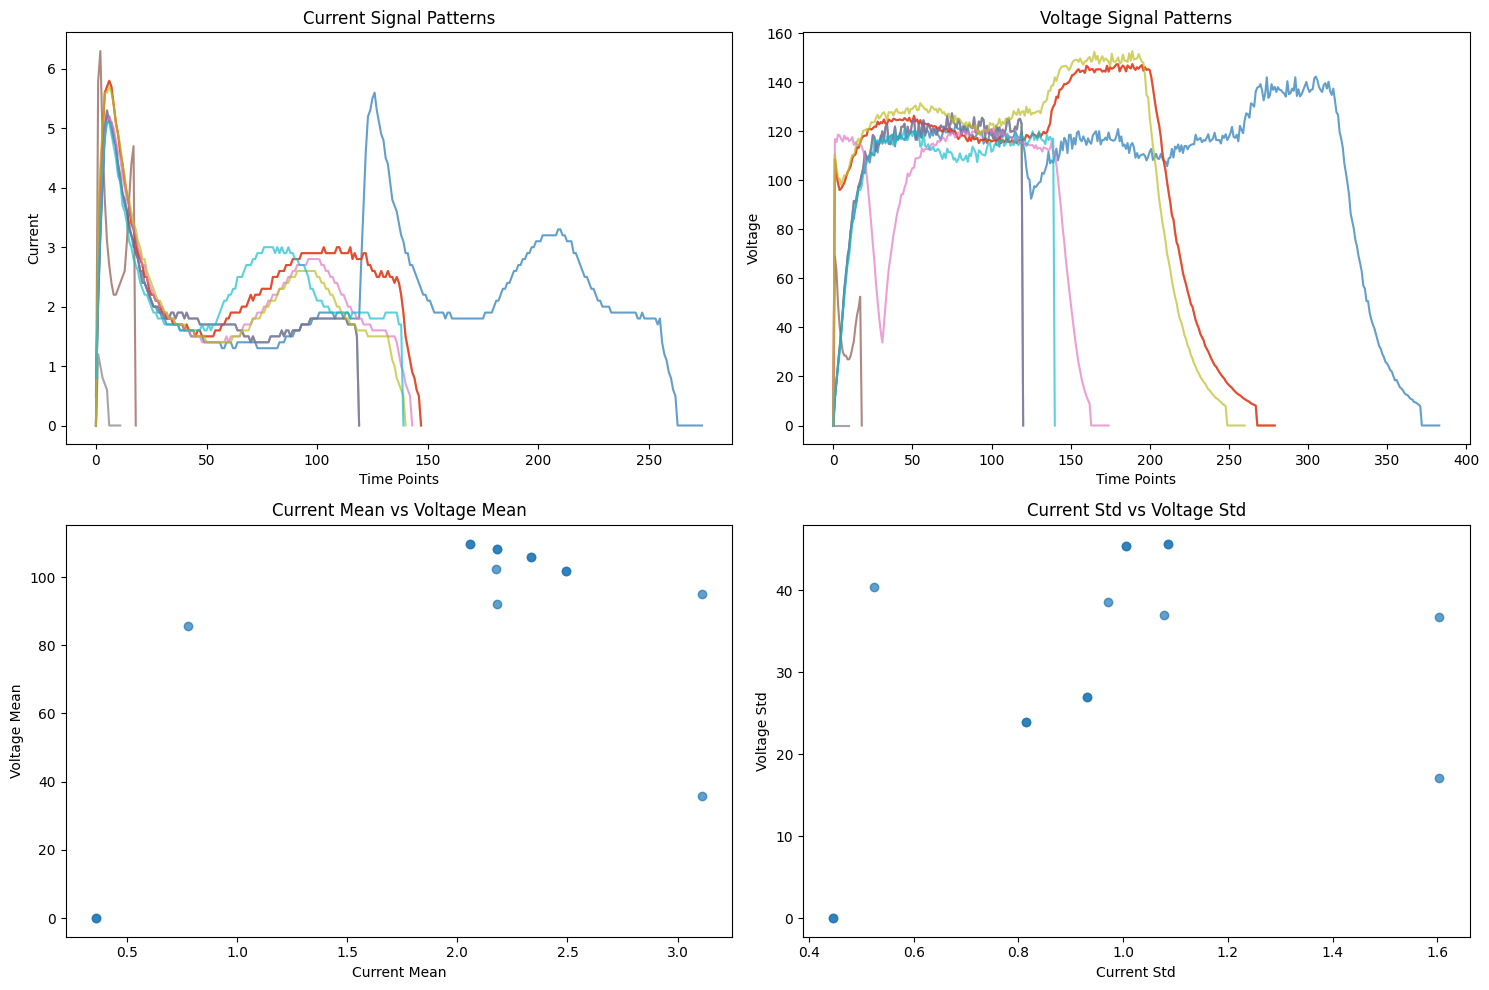

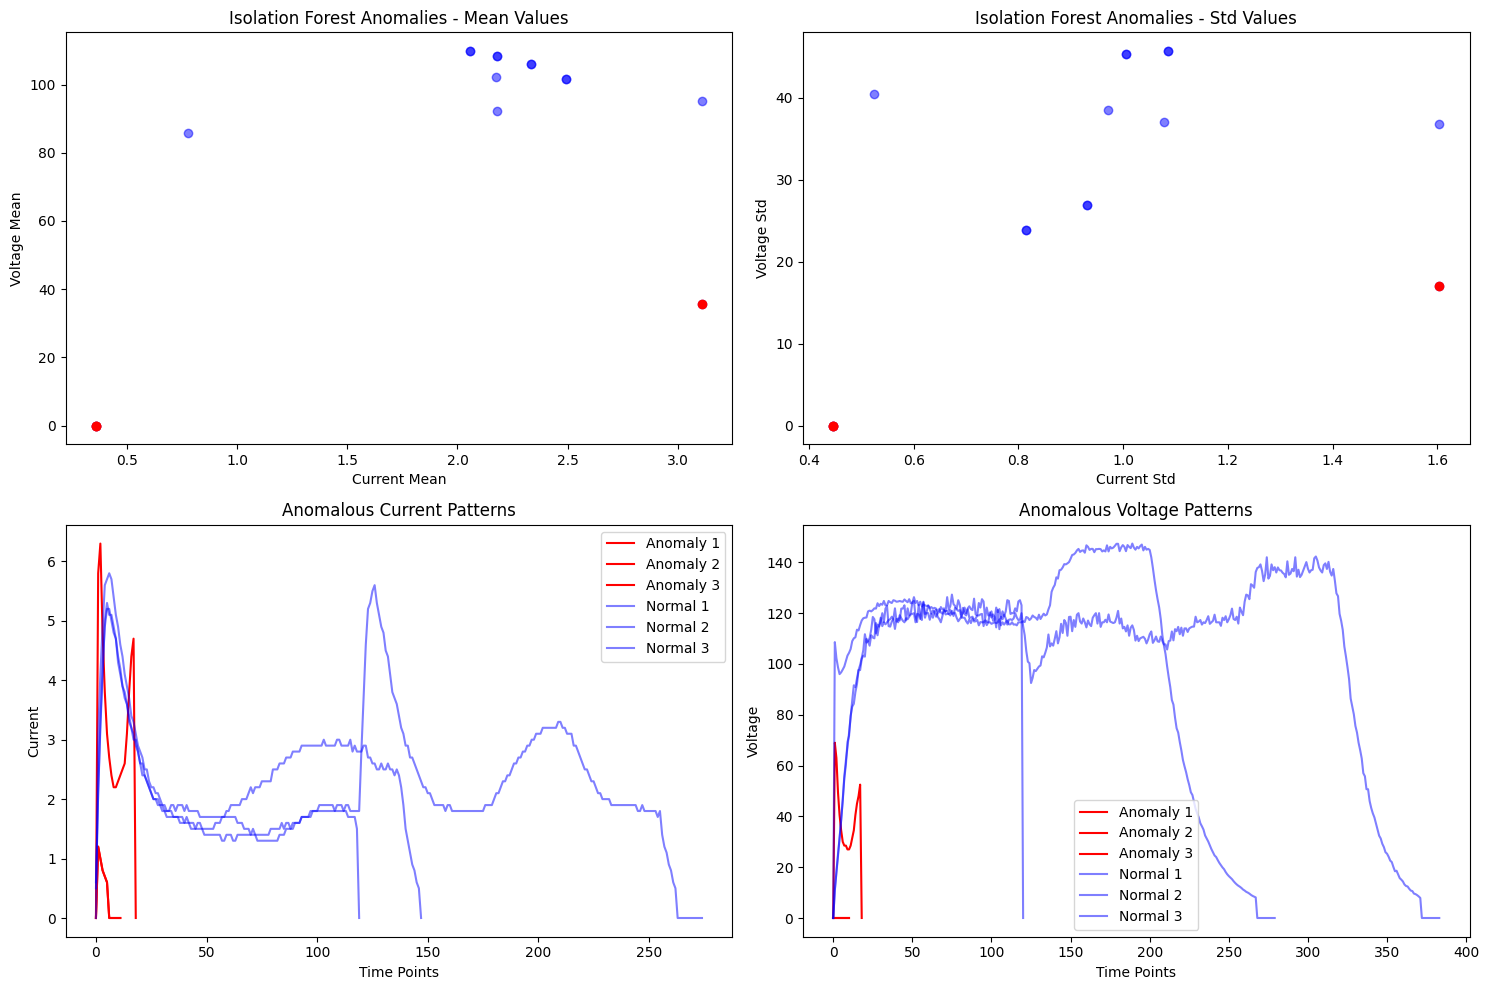

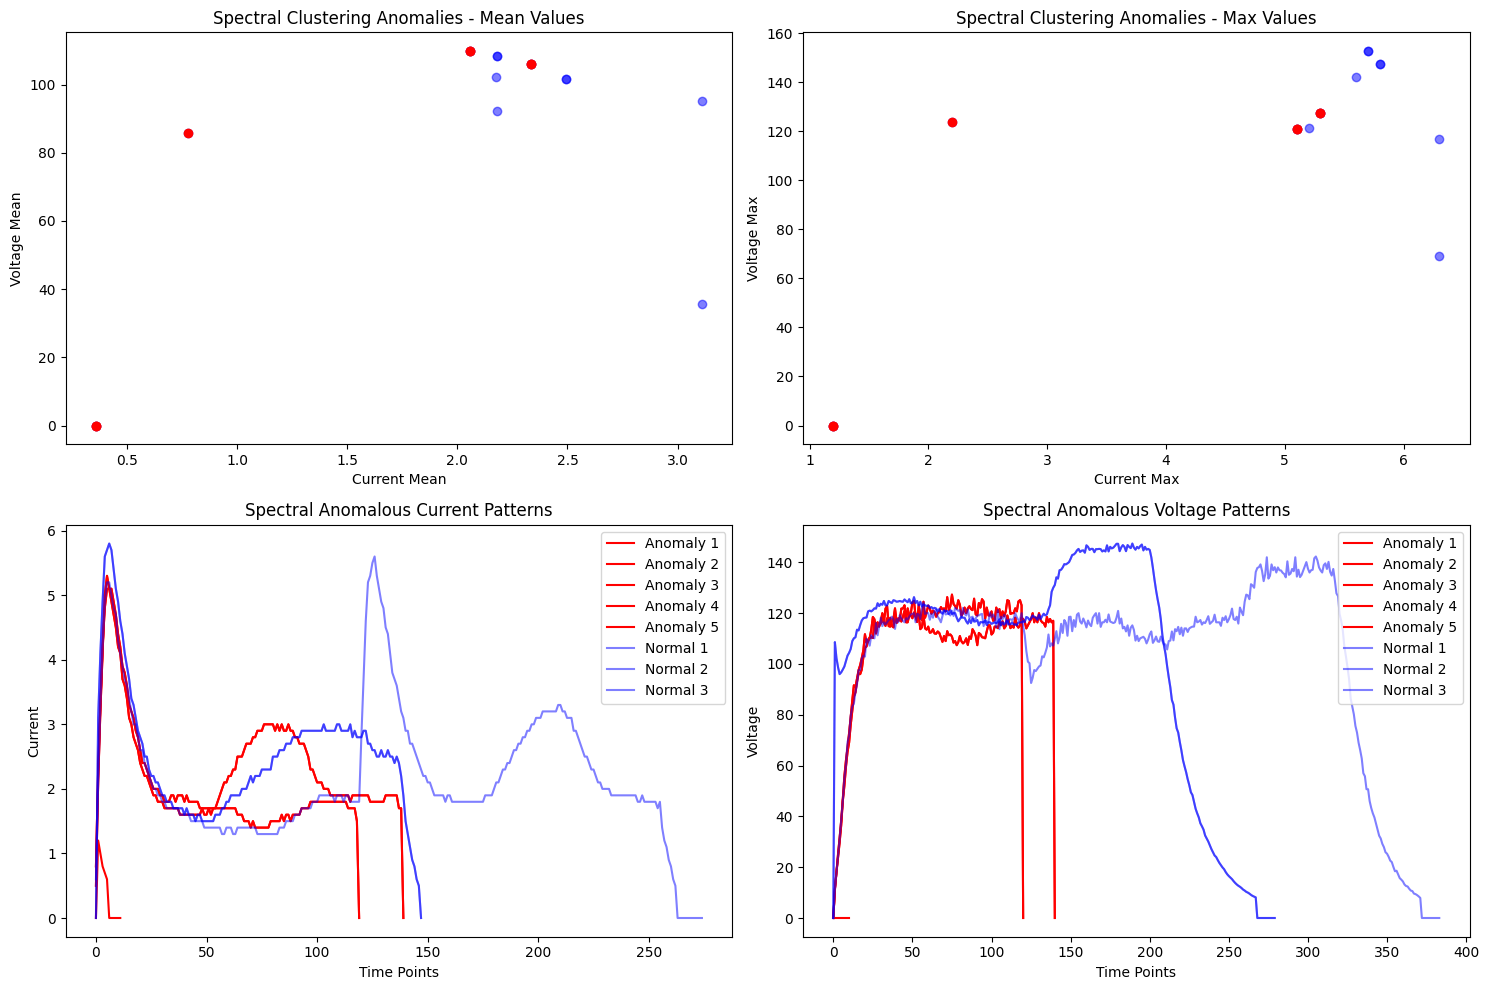

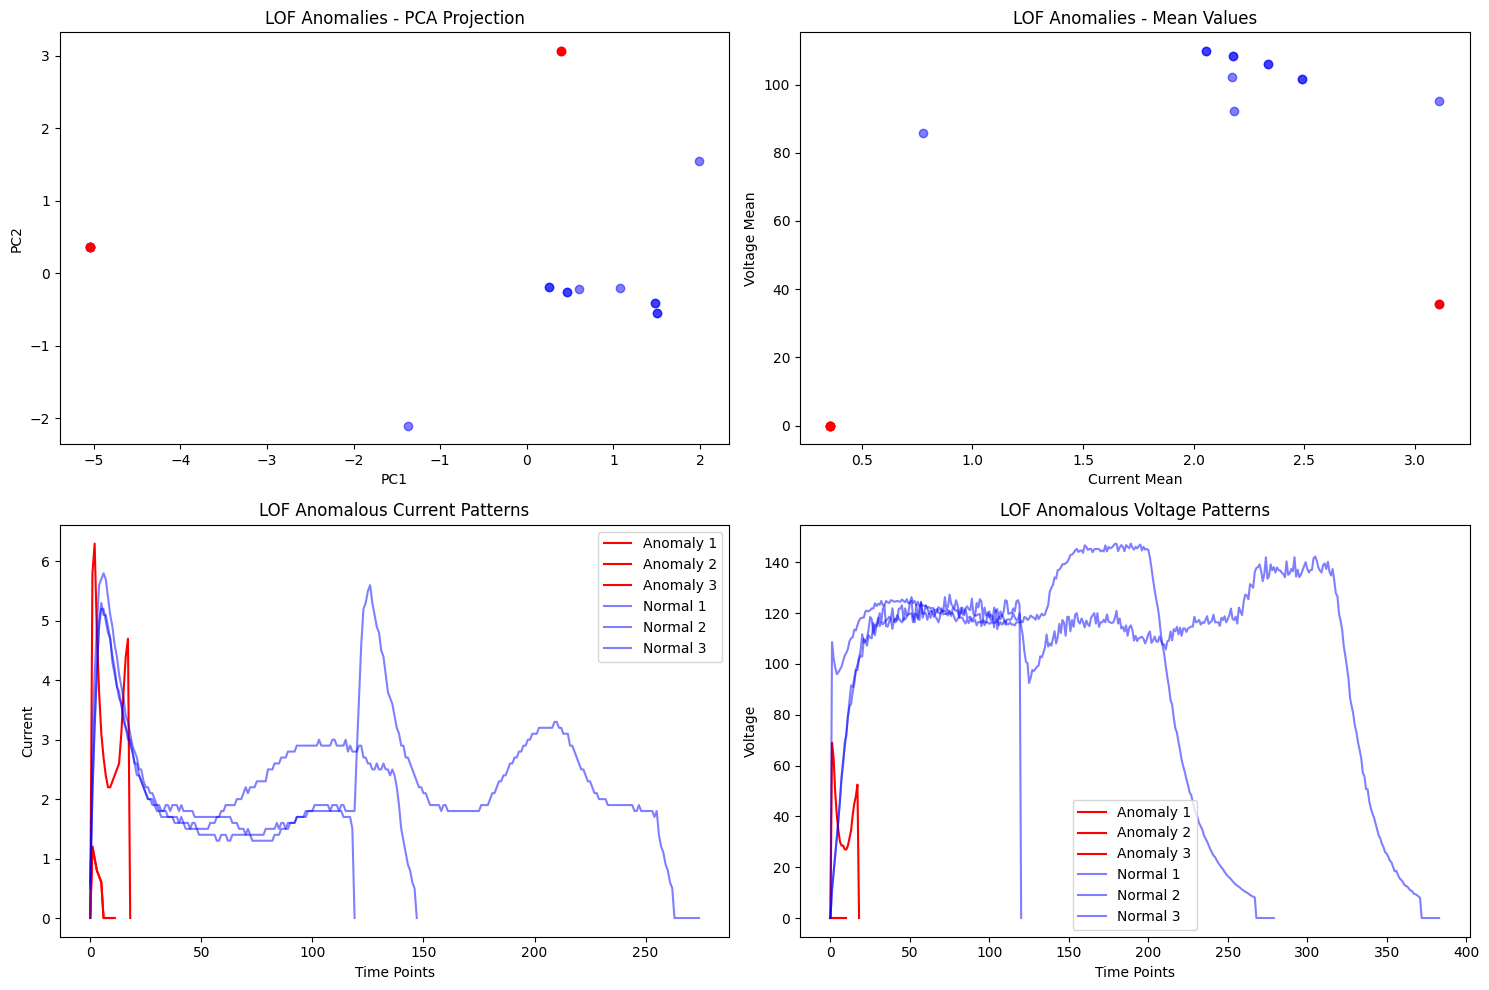

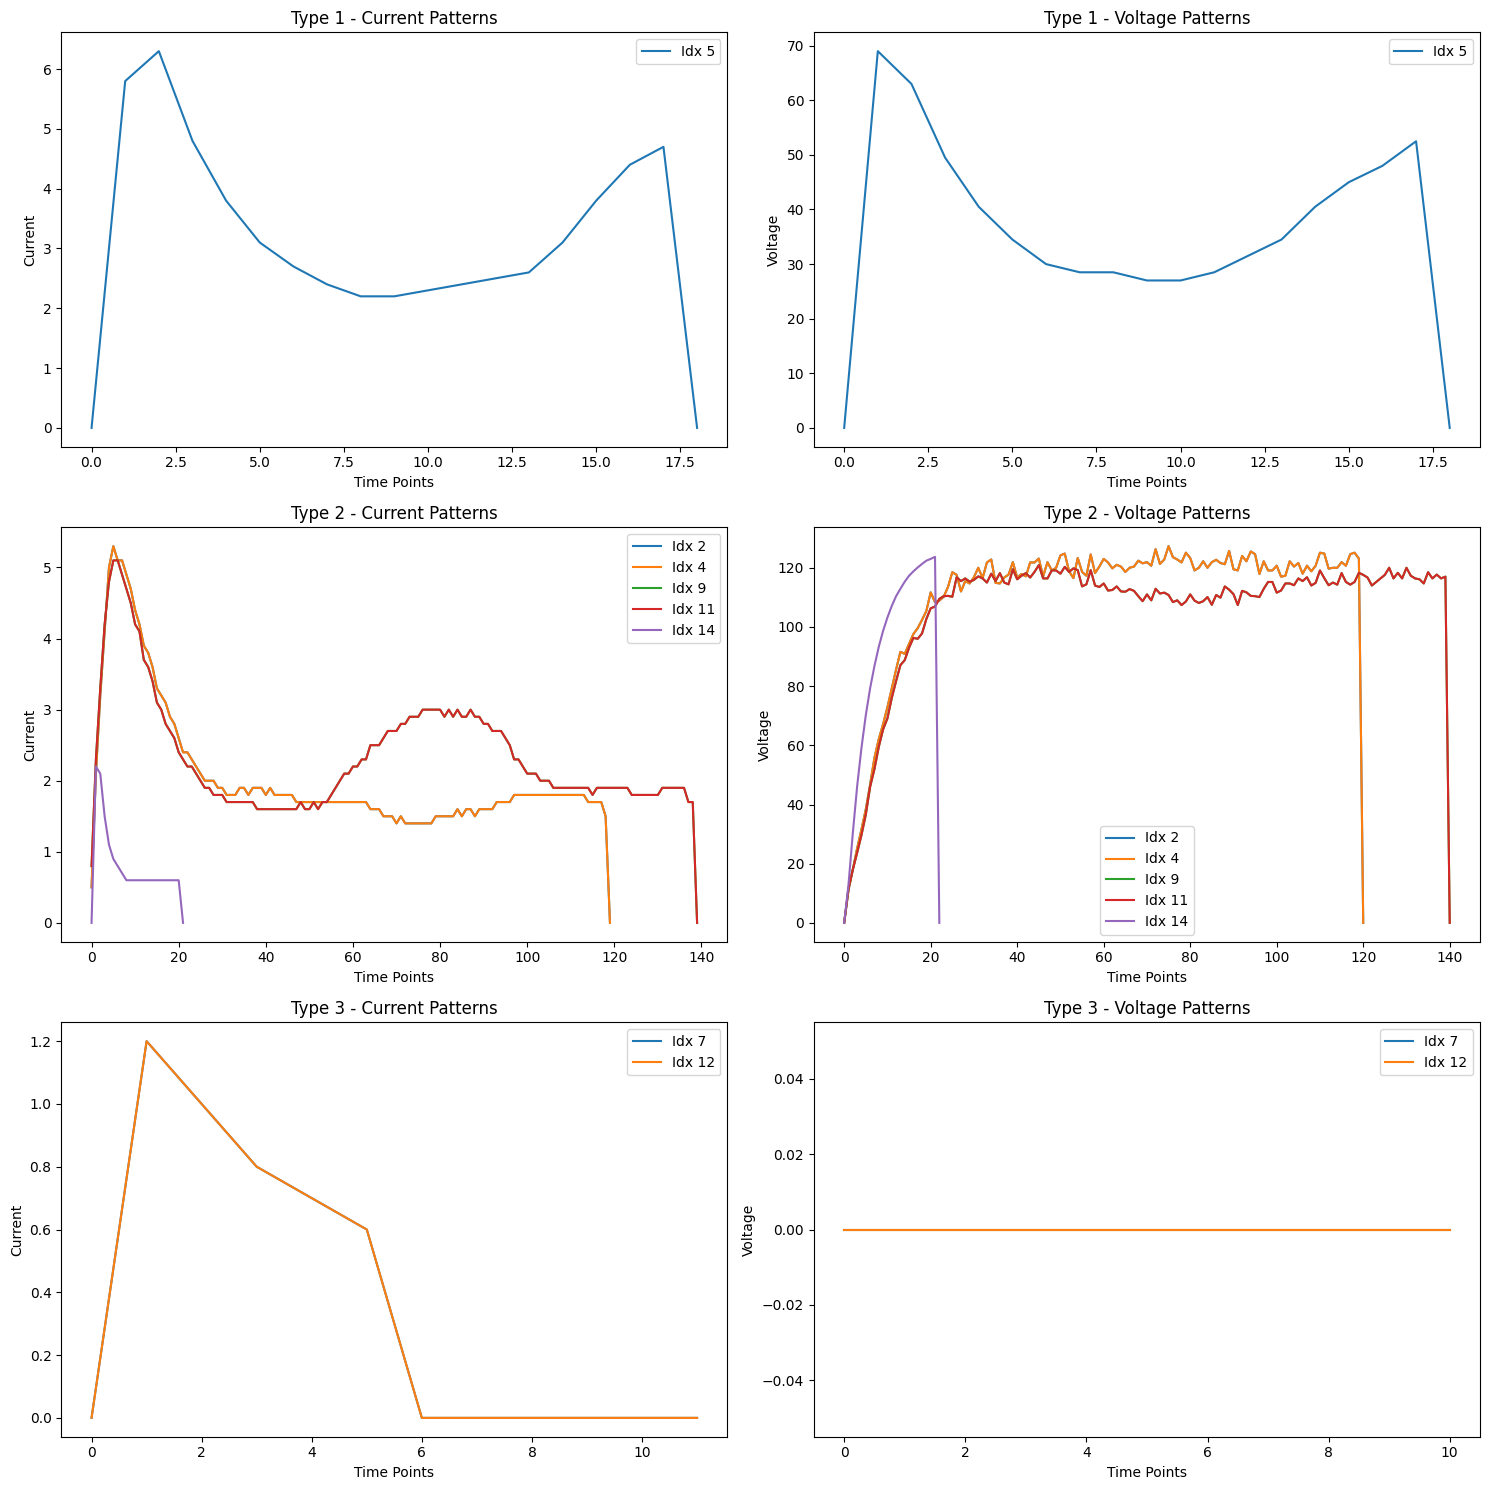

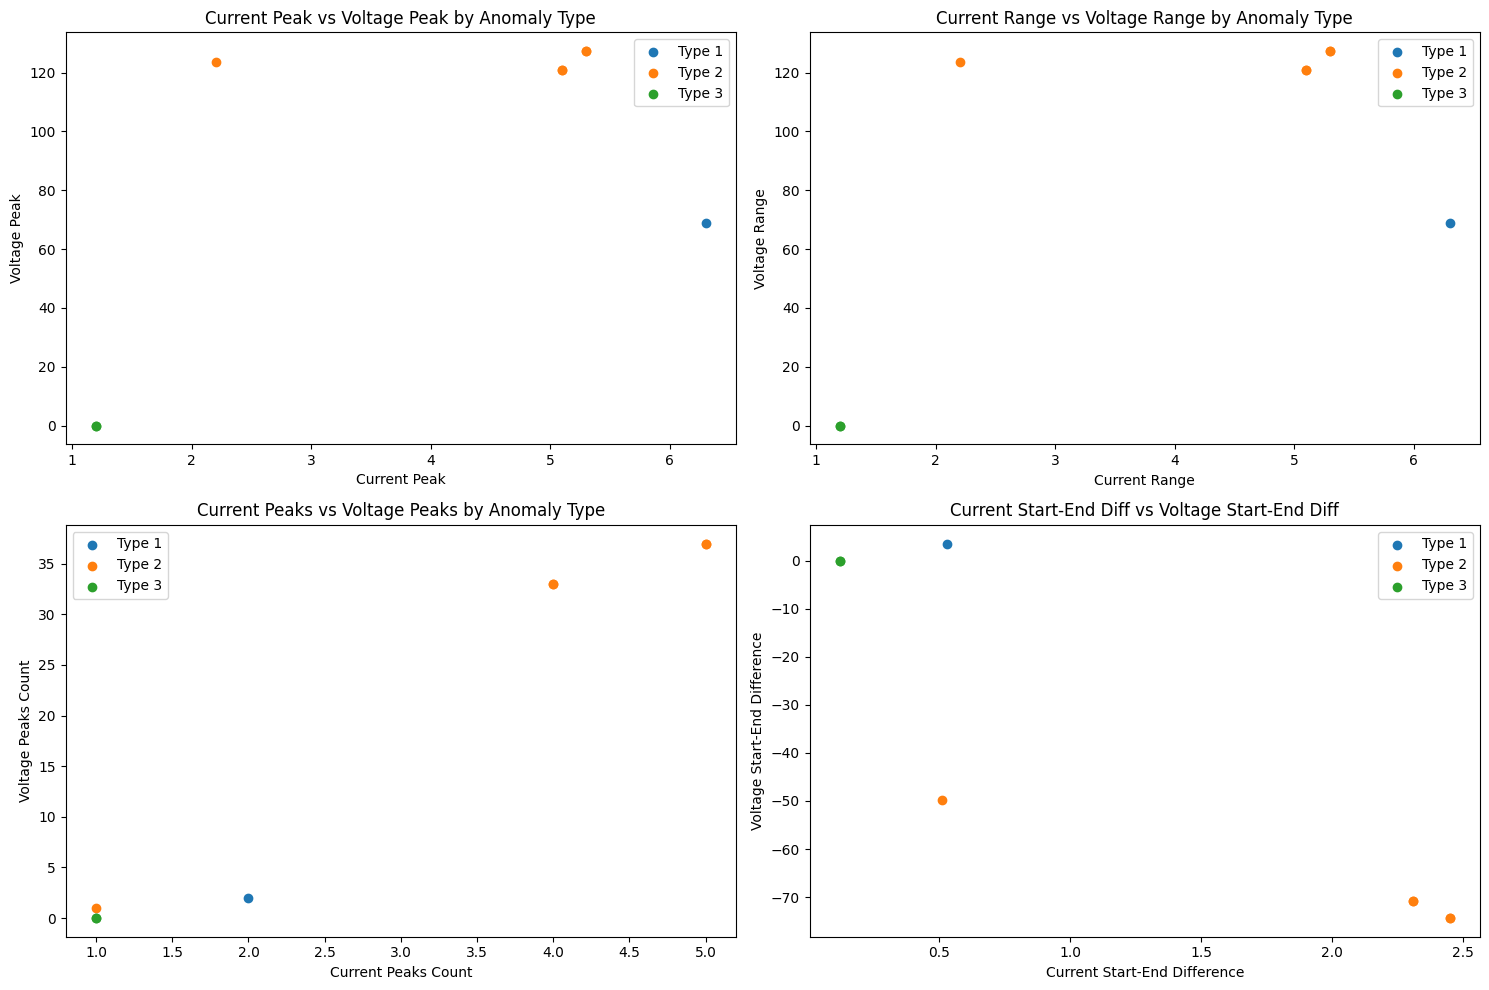


ANOMALY TYPE 1 (1 samples):
Current characteristics:
 - Average peak: 6.30
 - Average range: 6.30
 - Average peak count: 2.00
Voltage characteristics:
 - Average peak: 69.00
 - Average range: 69.00
 - Average peak count: 2.00
Current pattern type: Double peak
Voltage pattern type: Double peak

ANOMALY TYPE 2 (5 samples):
Current characteristics:
 - Average peak: 4.60
 - Average range: 4.60
 - Average peak count: 3.80
Voltage characteristics:
 - Average peak: 124.02
 - Average range: 124.02
 - Average peak count: 28.20
Current pattern type: Multiple peaks
Voltage pattern type: Multiple peaks

ANOMALY TYPE 3 (2 samples):
Current characteristics:
 - Average peak: 1.20
 - Average range: 1.20
 - Average peak count: 1.00
Voltage characteristics:
 - Average peak: 0.00
 - Average range: 0.00
 - Average peak count: 0.00
Current pattern type: Decreasing
Voltage pattern type: Increasing
Analysis completed for FEB 2025 Prototype data\Test_Zone.csv


In [39]:
file_path = 'FEB 2025 Prototype data\Test_Zone.csv'
analyze_dataset(file_path)

In [40]:
def plot_anomaly_time_series(df, anomalies_if, anomalies_spectral, anomalies_lof):
    all_anomalies = list(set(list(anomalies_if) + list(anomalies_spectral) + list(anomalies_lof)))
    
    plt.figure(figsize=(16, 12))
    
    plt.subplot(2, 1, 1)
    for i in range(len(df)):
        if i in all_anomalies:
            plt.plot(range(len(df.iloc[i]['A_Current_Values'])), 
                     df.iloc[i]['A_Current_Values'], 'r-', alpha=0.7)
        else:
            plt.plot(range(len(df.iloc[i]['A_Current_Values'])), 
                     df.iloc[i]['A_Current_Values'], 'b-', alpha=0.3)
    
    plt.title('All Current Signals (Red = Anomalies)')
    plt.xlabel('Time Points')
    plt.ylabel('Current')
    
    plt.subplot(2, 1, 2)
    for i in range(len(df)):
        if i in all_anomalies:
            plt.plot(range(len(df.iloc[i]['A_Voltage_Values'])), 
                     df.iloc[i]['A_Voltage_Values'], 'r-', alpha=0.7)
        else:
            plt.plot(range(len(df.iloc[i]['A_Voltage_Values'])), 
                     df.iloc[i]['A_Voltage_Values'], 'b-', alpha=0.3)
    
    plt.title('All Voltage Signals (Red = Anomalies)')
    plt.xlabel('Time Points')
    plt.ylabel('Voltage')
    
    plt.tight_layout()
    plt.show()

In [41]:
def plot_signal_comparison_by_feature(df, anomalies_if, anomalies_spectral, anomalies_lof):
    all_anomalies = list(set(list(anomalies_if) + list(anomalies_spectral) + list(anomalies_lof)))
    
    plt.figure(figsize=(16, 16))
    
    plt.subplot(2, 2, 1)
    plt.scatter(df['A_Current_Mean'], df['A_Current_Max'], c='blue', alpha=0.5)
    if all_anomalies:
        plt.scatter(df.iloc[all_anomalies]['A_Current_Mean'], 
                    df.iloc[all_anomalies]['A_Current_Max'], c='red')
    plt.title('Current Mean vs Current Max')
    plt.xlabel('Current Mean')
    plt.ylabel('Current Max')
    
    plt.subplot(2, 2, 2)
    plt.scatter(df['A_Voltage_Mean'], df['A_Voltage_Max'], c='blue', alpha=0.5)
    if all_anomalies:
        plt.scatter(df.iloc[all_anomalies]['A_Voltage_Mean'], 
                    df.iloc[all_anomalies]['A_Voltage_Max'], c='red')
    plt.title('Voltage Mean vs Voltage Max')
    plt.xlabel('Voltage Mean')
    plt.ylabel('Voltage Max')
    
    plt.subplot(2, 2, 3)
    plt.scatter(df['A_Current_Std'], df['A_Current_Max'], c='blue', alpha=0.5)
    if all_anomalies:
        plt.scatter(df.iloc[all_anomalies]['A_Current_Std'], 
                    df.iloc[all_anomalies]['A_Current_Max'], c='red')
    plt.title('Current Std vs Current Max')
    plt.xlabel('Current Std')
    plt.ylabel('Current Max')
    
    plt.subplot(2, 2, 4)
    plt.scatter(df['A_Voltage_Std'], df['A_Voltage_Max'], c='blue', alpha=0.5)
    if all_anomalies:
        plt.scatter(df.iloc[all_anomalies]['A_Voltage_Std'], 
                    df.iloc[all_anomalies]['A_Voltage_Max'], c='red')
    plt.title('Voltage Std vs Voltage Max')
    plt.xlabel('Voltage Std')
    plt.ylabel('Voltage Max')
    
    plt.tight_layout()
    plt.show()

In [42]:
def visualize_signal_derivatives(df, anomalies_if, anomalies_spectral, anomalies_lof):
    all_anomalies = list(set(list(anomalies_if) + list(anomalies_spectral) + list(anomalies_lof)))
    
    plt.figure(figsize=(16, 16))
    
    max_subplots = min(9, len(all_anomalies) + 3)
    anomaly_indices = all_anomalies[:min(6, len(all_anomalies))]
    normal_indices = [i for i in range(len(df)) if i not in all_anomalies][:3]
    
    plot_indices = anomaly_indices + normal_indices
    plot_colors = ['r'] * len(anomaly_indices) + ['b'] * len(normal_indices)
    plot_types = ['Anomaly'] * len(anomaly_indices) + ['Normal'] * len(normal_indices)
    
    for i, (idx, color, ptype) in enumerate(zip(plot_indices, plot_colors, plot_types)):
        if i >= max_subplots:
            break
            
        curr_values = df.iloc[idx]['A_Current_Values']
        volt_values = df.iloc[idx]['A_Voltage_Values']
        
        if len(curr_values) > 1:
            curr_derivative = np.diff(curr_values)
            plt.subplot(3, 3, i+1)
            plt.plot(curr_values, f'{color}-', label='Current')
            plt.plot(np.arange(1, len(curr_values)), curr_derivative, f'{color}--', alpha=0.7, label='Derivative')
            plt.title(f'{ptype} {idx} - Current with Derivative')
            plt.xlabel('Time Points')
            plt.ylabel('Value')
            plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(16, 16))
    
    for i, (idx, color, ptype) in enumerate(zip(plot_indices, plot_colors, plot_types)):
        if i >= max_subplots:
            break
            
        volt_values = df.iloc[idx]['A_Voltage_Values']
        
        if len(volt_values) > 1:
            volt_derivative = np.diff(volt_values)
            plt.subplot(3, 3, i+1)
            plt.plot(volt_values, f'{color}-', label='Voltage')
            plt.plot(np.arange(1, len(volt_values)), volt_derivative, f'{color}--', alpha=0.7, label='Derivative')
            plt.title(f'{ptype} {idx} - Voltage with Derivative')
            plt.xlabel('Time Points')
            plt.ylabel('Value')
            plt.legend()
    
    plt.tight_layout()
    plt.show()

In [43]:
def create_3d_visualization(df, anomalies_if, anomalies_spectral, anomalies_lof):
    from mpl_toolkits.mplot3d import Axes3D
    
    all_anomalies = list(set(list(anomalies_if) + list(anomalies_spectral) + list(anomalies_lof)))
    
    fig = plt.figure(figsize=(15, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    normal_indices = [i for i in range(len(df)) if i not in all_anomalies]
    
    ax.scatter(
        df.iloc[normal_indices]['A_Current_Mean'],
        df.iloc[normal_indices]['A_Current_Std'],
        df.iloc[normal_indices]['A_Voltage_Mean'],
        c='blue', marker='o', alpha=0.6, label='Normal'
    )
    
    if all_anomalies:
        ax.scatter(
            df.iloc[all_anomalies]['A_Current_Mean'],
            df.iloc[all_anomalies]['A_Current_Std'],
            df.iloc[all_anomalies]['A_Voltage_Mean'],
            c='red', marker='^', alpha=1.0, s=100, label='Anomaly'
        )
    
    ax.set_xlabel('Current Mean')
    ax.set_ylabel('Current Std')
    ax.set_zlabel('Voltage Mean')
    ax.set_title('3D Visualization of Signal Features')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    fig = plt.figure(figsize=(15, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(
        df.iloc[normal_indices]['A_Current_Max'],
        df.iloc[normal_indices]['A_Current_Mean'],
        df.iloc[normal_indices]['A_Voltage_Max'],
        c='blue', marker='o', alpha=0.6, label='Normal'
    )
    
    if all_anomalies:
        ax.scatter(
            df.iloc[all_anomalies]['A_Current_Max'],
            df.iloc[all_anomalies]['A_Current_Mean'],
            df.iloc[all_anomalies]['A_Voltage_Max'],
            c='red', marker='^', alpha=1.0, s=100, label='Anomaly'
        )
    
    ax.set_xlabel('Current Max')
    ax.set_ylabel('Current Mean')
    ax.set_zlabel('Voltage Max')
    ax.set_title('3D Visualization of Max vs Mean Features')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

In [44]:
def visualize_signal_heatmaps(df, anomalies_if, anomalies_spectral, anomalies_lof):
    all_anomalies = list(set(list(anomalies_if) + list(anomalies_spectral) + list(anomalies_lof)))
    
    feature_cols = ['A_Current_Mean', 'A_Current_Std', 'A_Current_Max', 'A_Current_Min',
                    'A_Voltage_Mean', 'A_Voltage_Std', 'A_Voltage_Max', 'A_Voltage_Min']
    
    normal_df = df.iloc[[i for i in range(len(df)) if i not in all_anomalies]]
    anomaly_df = df.iloc[all_anomalies] if all_anomalies else pd.DataFrame(columns=feature_cols)
    
    plt.figure(figsize=(20, 8))
    
    plt.subplot(1, 2, 1)
    if len(normal_df) > 1:
        corr_matrix = normal_df[feature_cols].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Feature Correlation Matrix - Normal Signals')
    else:
        plt.text(0.5, 0.5, 'Not enough normal samples for correlation', 
                 horizontalalignment='center', verticalalignment='center')
    
    plt.subplot(1, 2, 2)
    if len(anomaly_df) > 1:
        corr_matrix = anomaly_df[feature_cols].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
        plt.title('Feature Correlation Matrix - Anomalous Signals')
    else:
        plt.text(0.5, 0.5, 'Not enough anomaly samples for correlation', 
                 horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    plt.show()

In [45]:
def compute_spectral_analysis(df, anomalies_if, anomalies_spectral, anomalies_lof):
    from scipy import signal
    from scipy.fft import fft, fftfreq
    
    all_anomalies = list(set(list(anomalies_if) + list(anomalies_spectral) + list(anomalies_lof)))
    normal_indices = [i for i in range(len(df)) if i not in all_anomalies]
    
    if not all_anomalies or not normal_indices:
        print("Not enough samples for comparison")
        return
    
    plt.figure(figsize=(16, 16))
    
    anomaly_samples = min(4, len(all_anomalies))
    normal_samples = min(4, len(normal_indices))
    
    for i in range(anomaly_samples):
        idx = all_anomalies[i]
        
        plt.subplot(anomaly_samples, 2, 2*i+1)
        
        current_values = df.iloc[idx]['A_Current_Values']
        if len(current_values) > 10:
            f, Pxx = signal.welch(current_values, fs=1.0, nperseg=min(len(current_values)//2, 256))
            plt.semilogy(f, Pxx)
            plt.title(f'Anomaly {idx} - Current PSD')
            plt.xlabel('Frequency')
            plt.ylabel('PSD')
        else:
            plt.text(0.5, 0.5, 'Signal too short for spectral analysis', 
                     horizontalalignment='center', verticalalignment='center')
        
        plt.subplot(anomaly_samples, 2, 2*i+2)
        
        voltage_values = df.iloc[idx]['A_Voltage_Values']
        if len(voltage_values) > 10:
            f, Pxx = signal.welch(voltage_values, fs=1.0, nperseg=min(len(voltage_values)//2, 256))
            plt.semilogy(f, Pxx)
            plt.title(f'Anomaly {idx} - Voltage PSD')
            plt.xlabel('Frequency')
            plt.ylabel('PSD')
        else:
            plt.text(0.5, 0.5, 'Signal too short for spectral analysis', 
                     horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(16, 16))
    
    for i in range(normal_samples):
        idx = normal_indices[i]
        
        plt.subplot(normal_samples, 2, 2*i+1)
        
        current_values = df.iloc[idx]['A_Current_Values']
        if len(current_values) > 10:
            f, Pxx = signal.welch(current_values, fs=1.0, nperseg=min(len(current_values)//2, 256))
            plt.semilogy(f, Pxx)
            plt.title(f'Normal {idx} - Current PSD')
            plt.xlabel('Frequency')
            plt.ylabel('PSD')
        else:
            plt.text(0.5, 0.5, 'Signal too short for spectral analysis', 
                     horizontalalignment='center', verticalalignment='center')
        
        plt.subplot(normal_samples, 2, 2*i+2)
        
        voltage_values = df.iloc[idx]['A_Voltage_Values']
        if len(voltage_values) > 10:
            f, Pxx = signal.welch(voltage_values, fs=1.0, nperseg=min(len(voltage_values)//2, 256))
            plt.semilogy(f, Pxx)
            plt.title(f'Normal {idx} - Voltage PSD')
            plt.xlabel('Frequency')
            plt.ylabel('PSD')
        else:
            plt.text(0.5, 0.5, 'Signal too short for spectral analysis', 
                     horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    plt.show()

In [46]:
def analyze_dataset_with_enhanced_graphs(file_path):
    print(f"Analyzing {file_path}")
    
    df = load_data(file_path)
    if df.empty:
        print(f"Failed to load dataset {file_path}")
        return
    
    processed_df = preprocess_data(df)
    if len(processed_df) < 2:
        print(f"Not enough data to process in {file_path}")
        return
    
    print(f"Processed {len(processed_df)} records")
    
    extract_signal_patterns(processed_df)
    
    anomalies_if = detect_anomalies_isolation_forest(processed_df)
    anomalies_spectral = detect_anomalies_spectral(processed_df)
    anomalies_lof = detect_local_outliers(processed_df)
    
    identify_anomaly_types(processed_df, anomalies_if, anomalies_spectral, anomalies_lof)
    
    print("Generating enhanced visualizations...")
    plot_anomaly_time_series(processed_df, anomalies_if, anomalies_spectral, anomalies_lof)
    plot_signal_comparison_by_feature(processed_df, anomalies_if, anomalies_spectral, anomalies_lof)
    visualize_signal_derivatives(processed_df, anomalies_if, anomalies_spectral, anomalies_lof)
    create_3d_visualization(processed_df, anomalies_if, anomalies_spectral, anomalies_lof)
    visualize_signal_heatmaps(processed_df, anomalies_if, anomalies_spectral, anomalies_lof)
    compute_spectral_analysis(processed_df, anomalies_if, anomalies_spectral, anomalies_lof)
    
    print(f"Analysis completed for {file_path}")

Analyzing FEB 2025 Prototype data\Test_Zone.csv
Processed 15 records


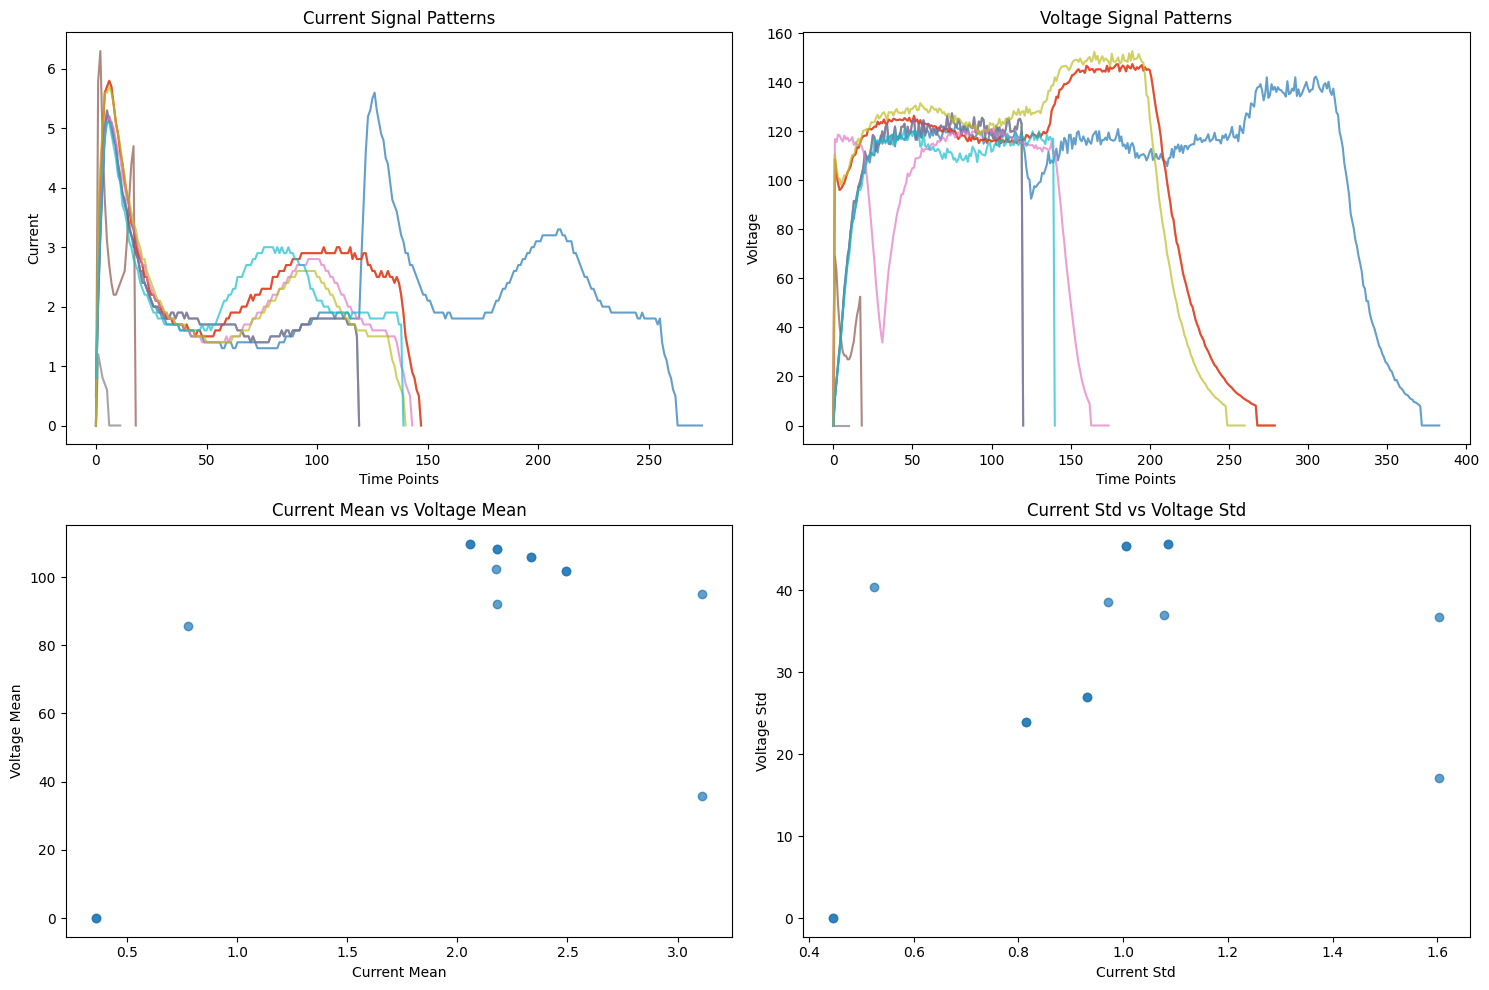

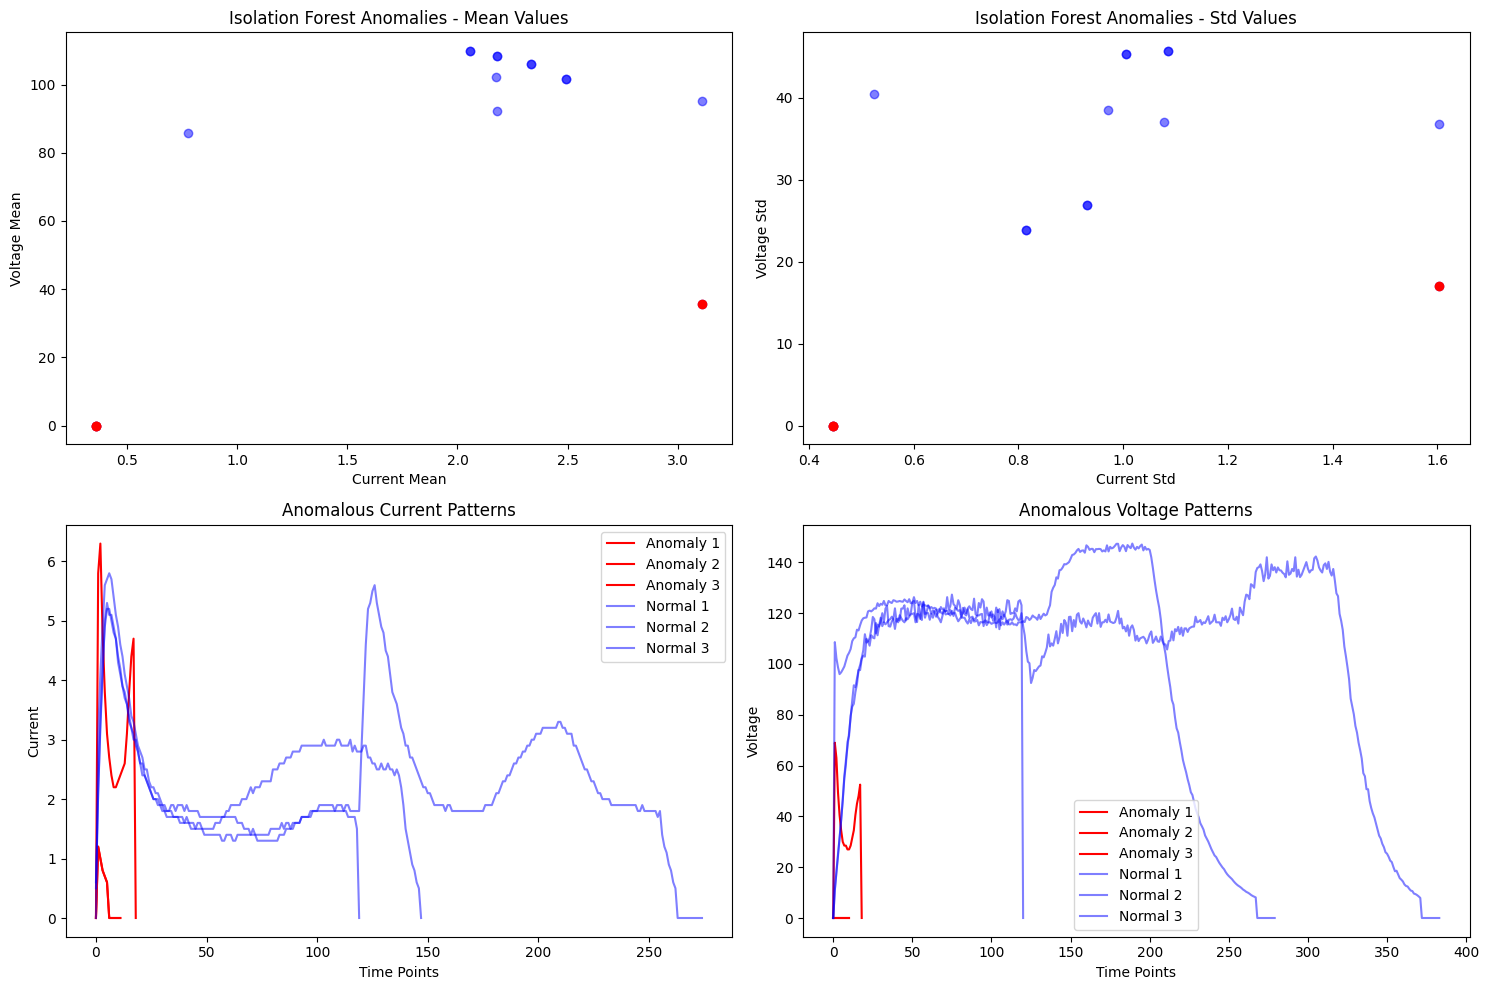

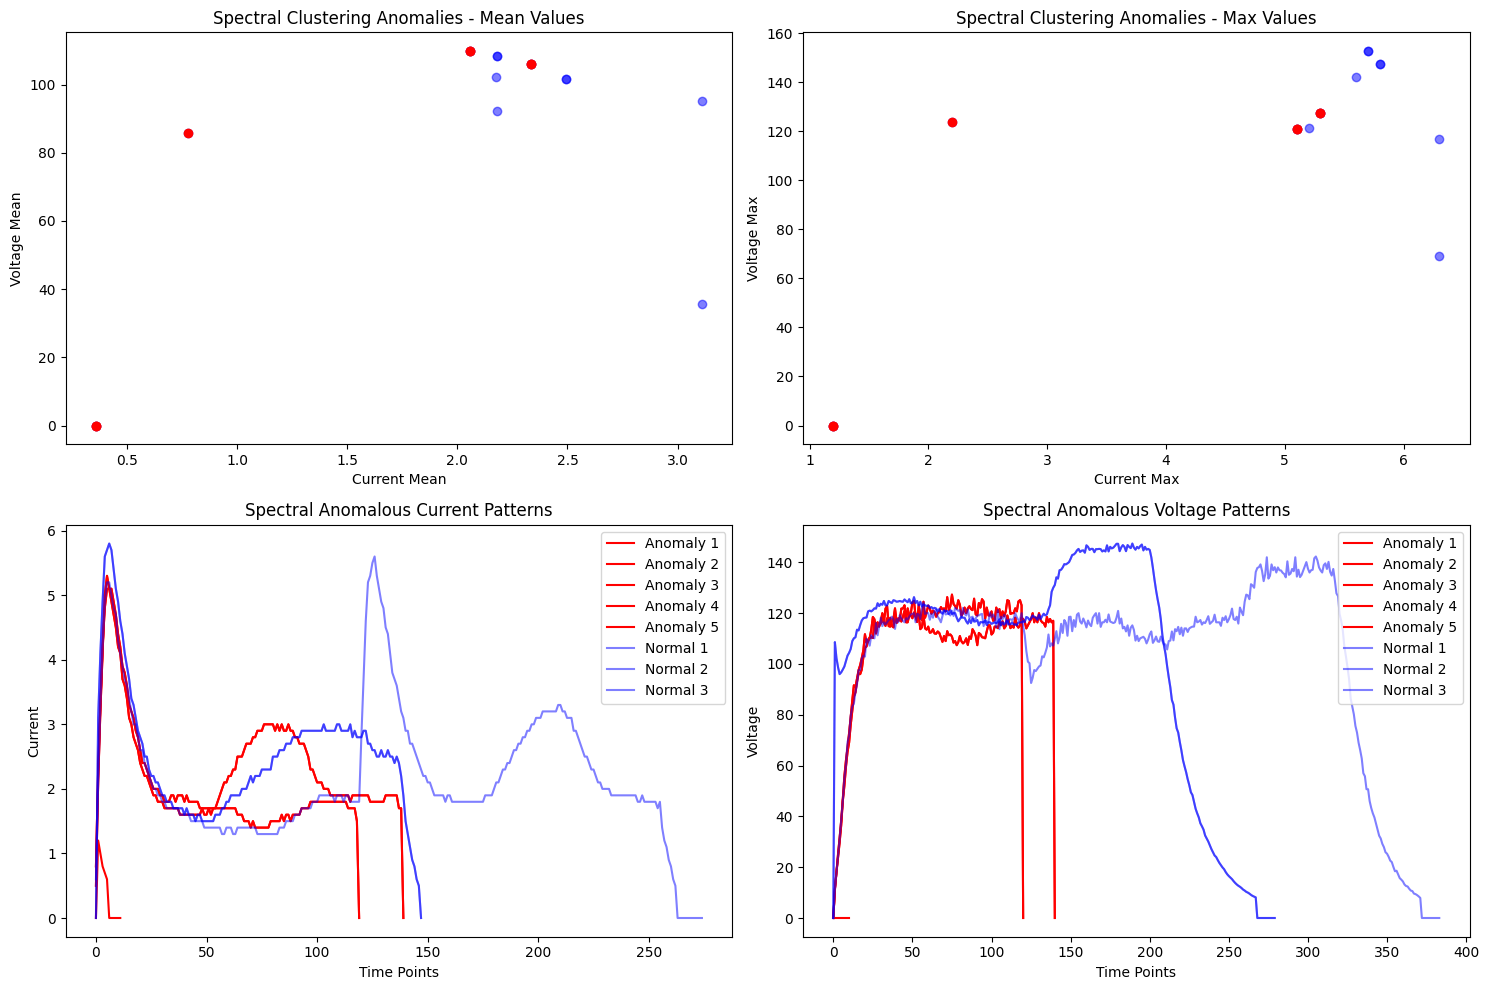

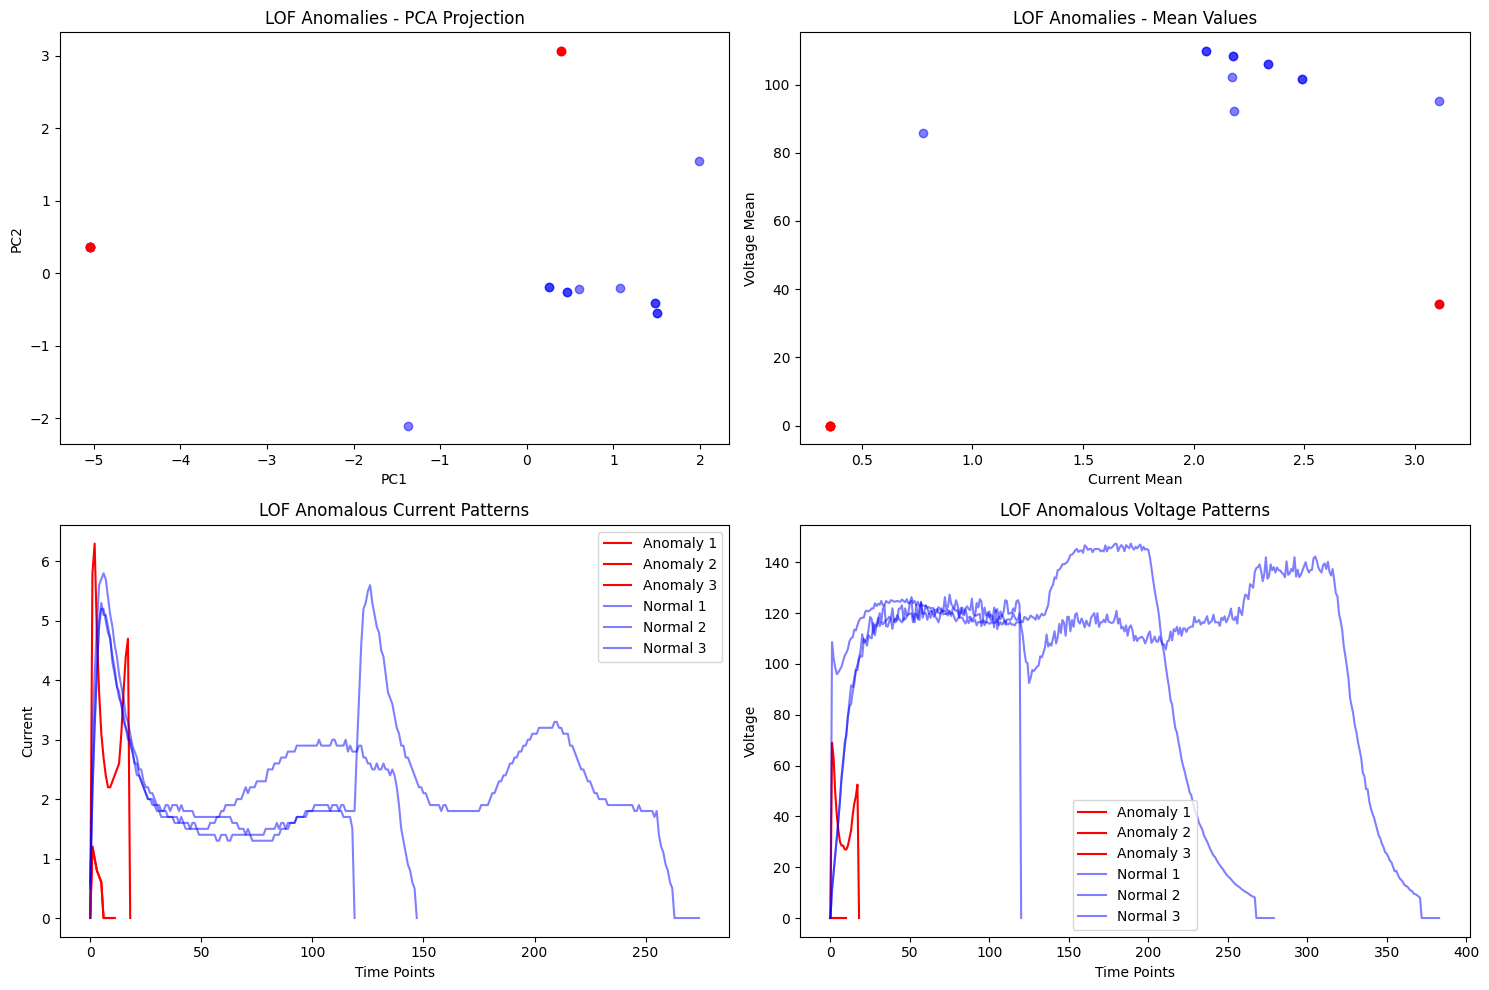

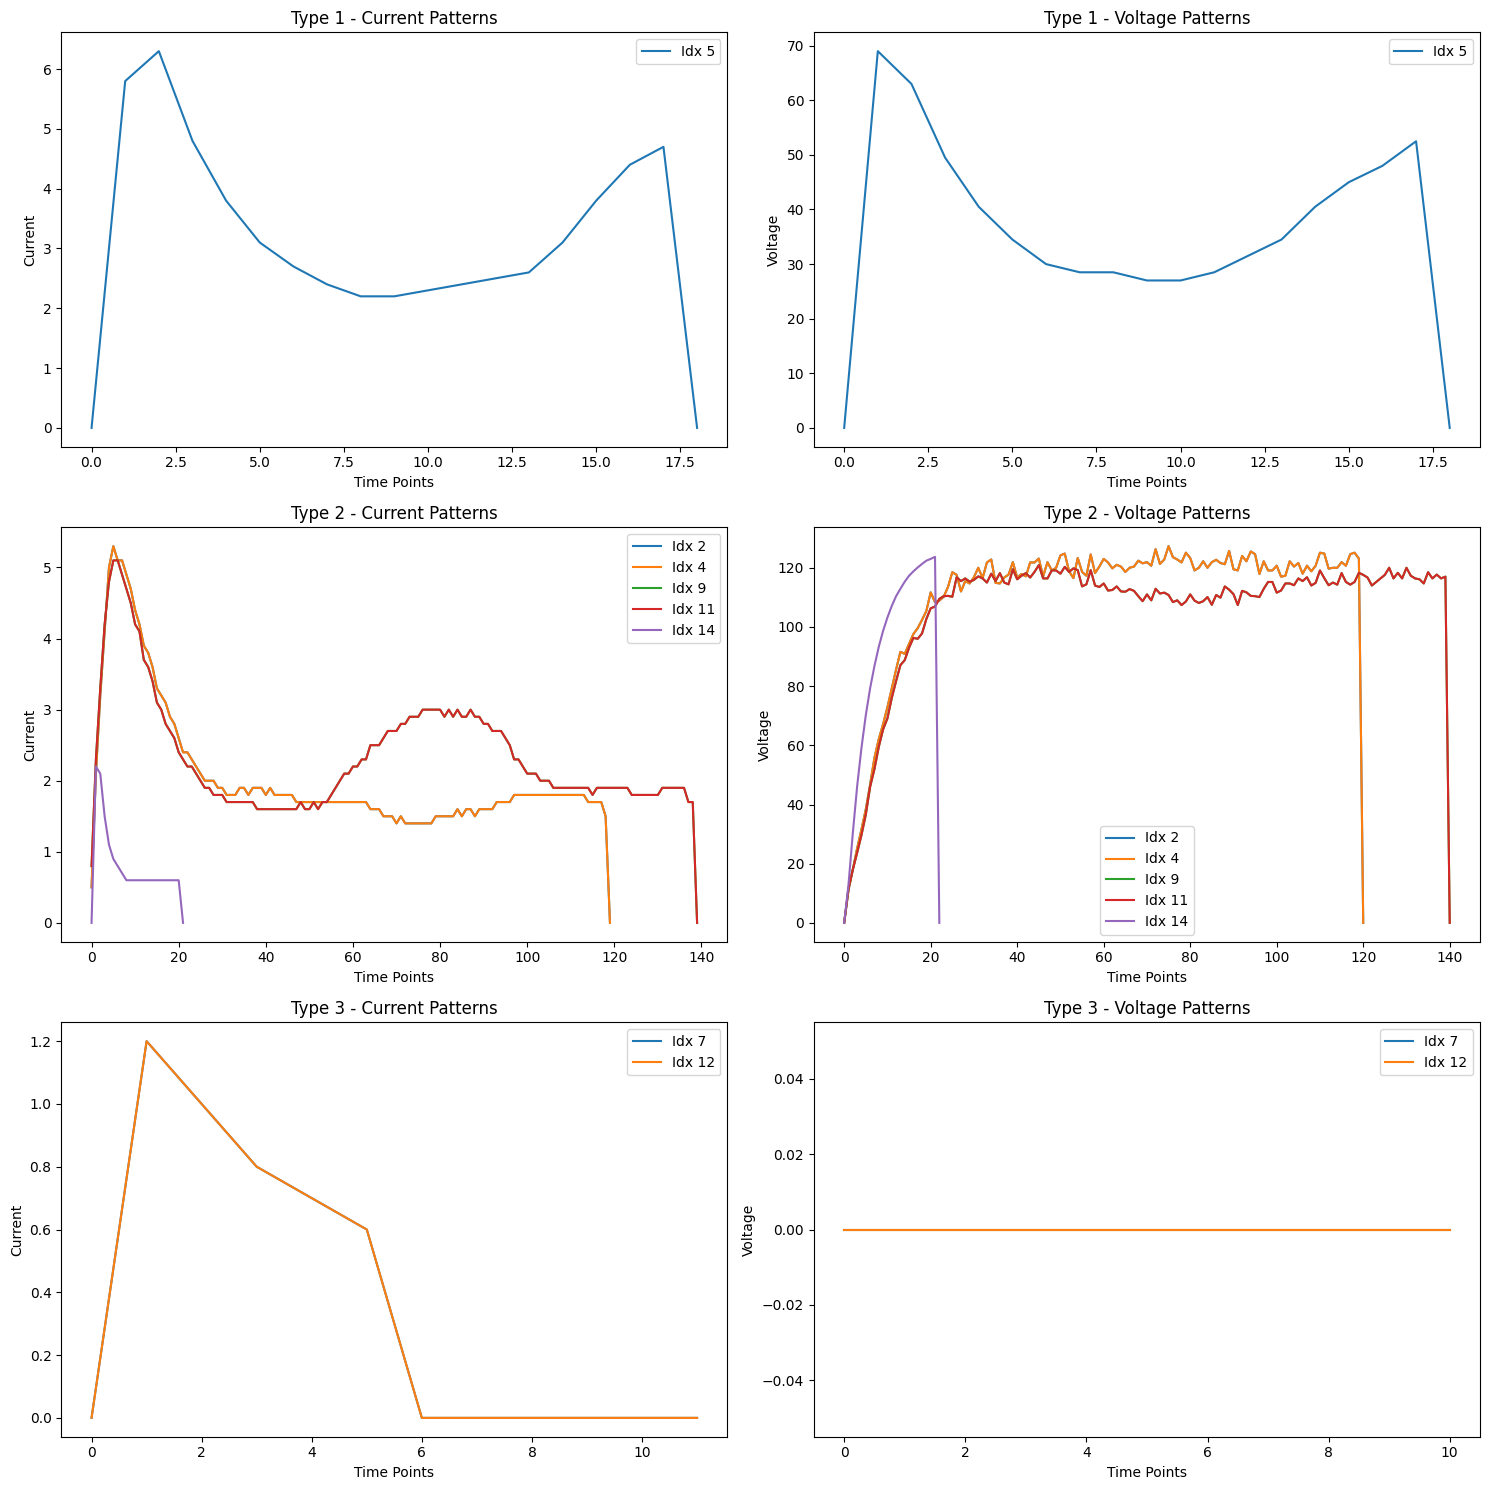

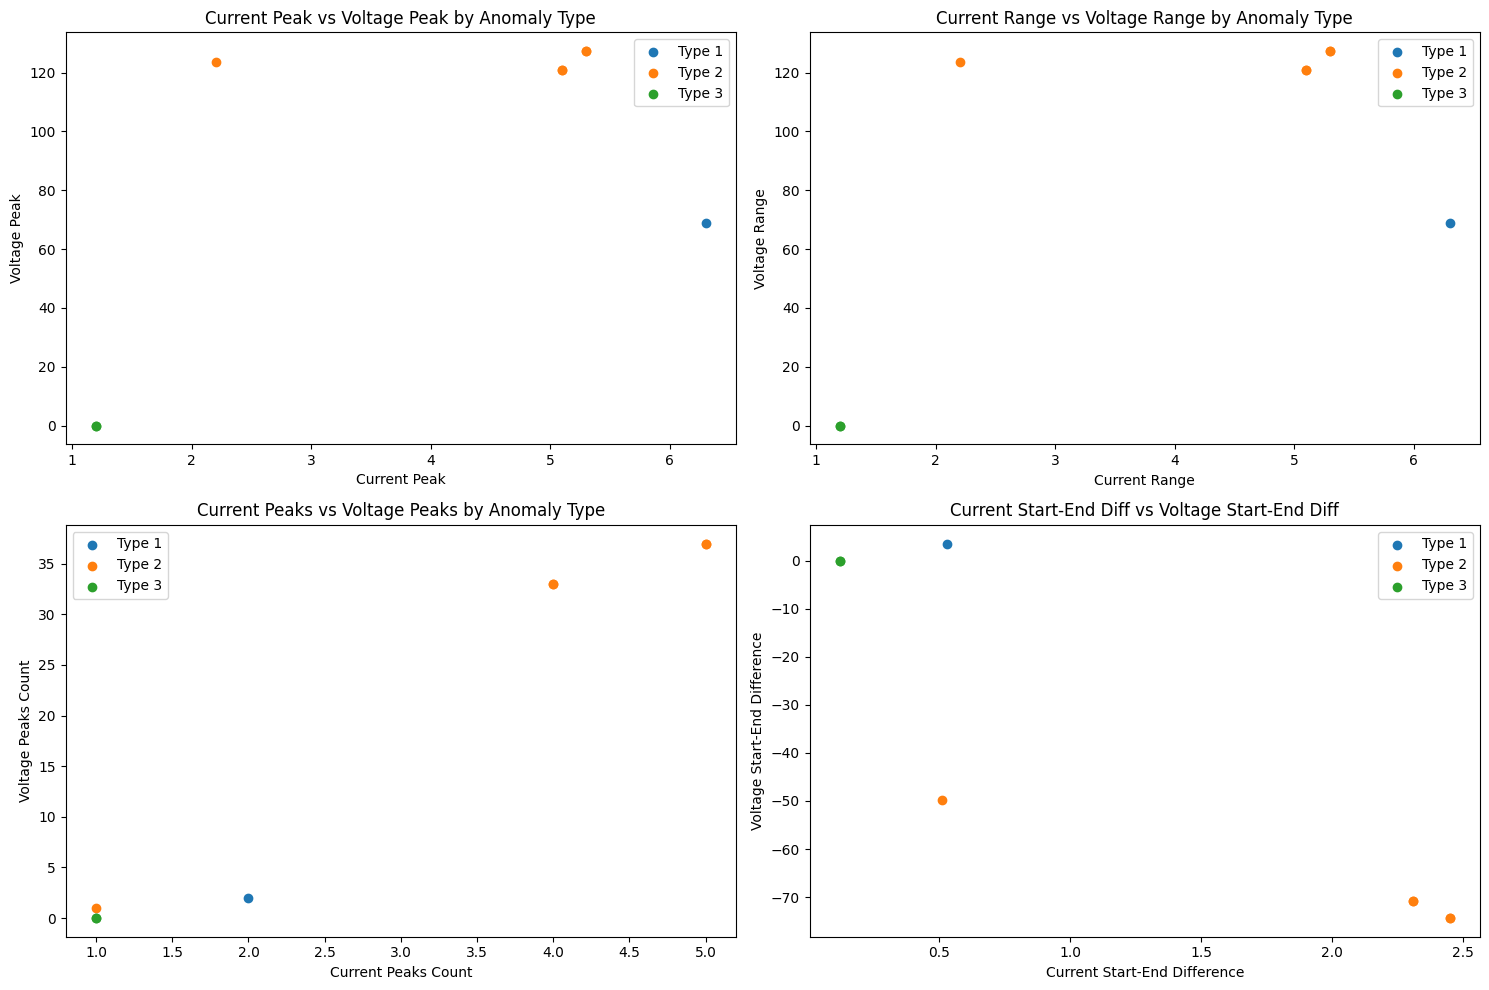


ANOMALY TYPE 1 (1 samples):
Current characteristics:
 - Average peak: 6.30
 - Average range: 6.30
 - Average peak count: 2.00
Voltage characteristics:
 - Average peak: 69.00
 - Average range: 69.00
 - Average peak count: 2.00
Current pattern type: Double peak
Voltage pattern type: Double peak

ANOMALY TYPE 2 (5 samples):
Current characteristics:
 - Average peak: 4.60
 - Average range: 4.60
 - Average peak count: 3.80
Voltage characteristics:
 - Average peak: 124.02
 - Average range: 124.02
 - Average peak count: 28.20
Current pattern type: Multiple peaks
Voltage pattern type: Multiple peaks

ANOMALY TYPE 3 (2 samples):
Current characteristics:
 - Average peak: 1.20
 - Average range: 1.20
 - Average peak count: 1.00
Voltage characteristics:
 - Average peak: 0.00
 - Average range: 0.00
 - Average peak count: 0.00
Current pattern type: Decreasing
Voltage pattern type: Increasing
Generating enhanced visualizations...


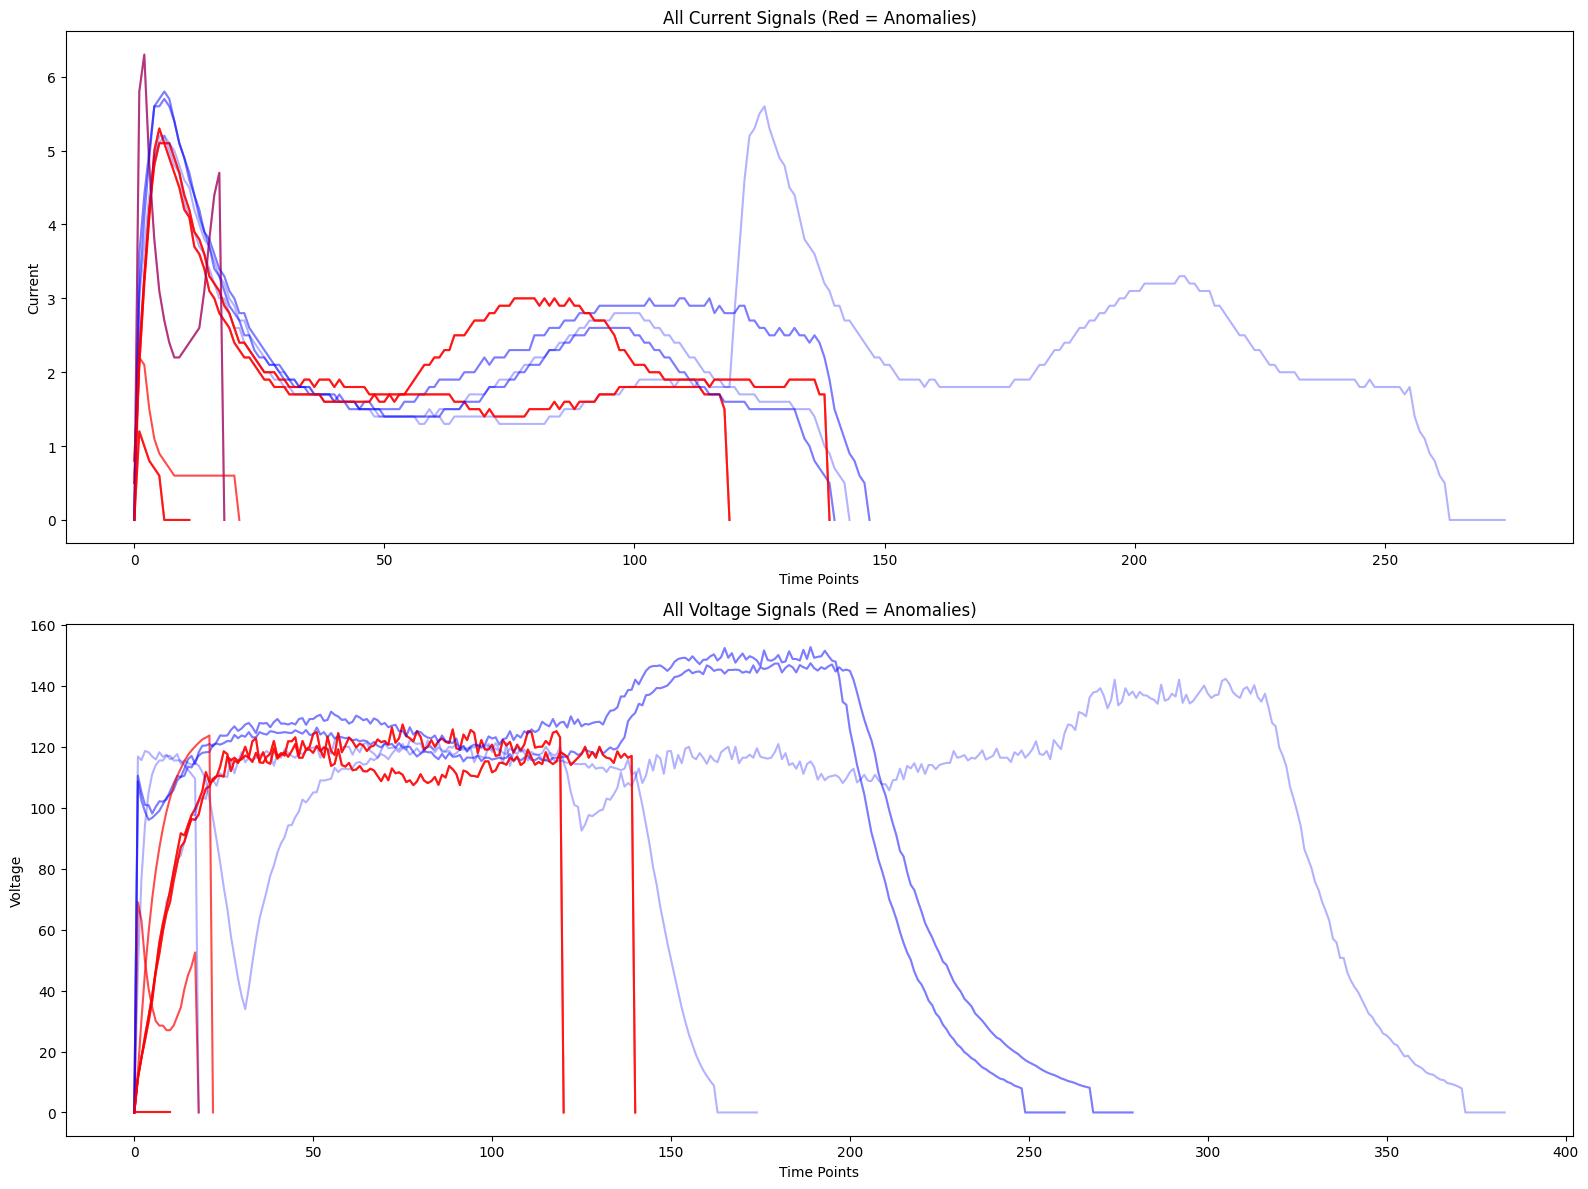

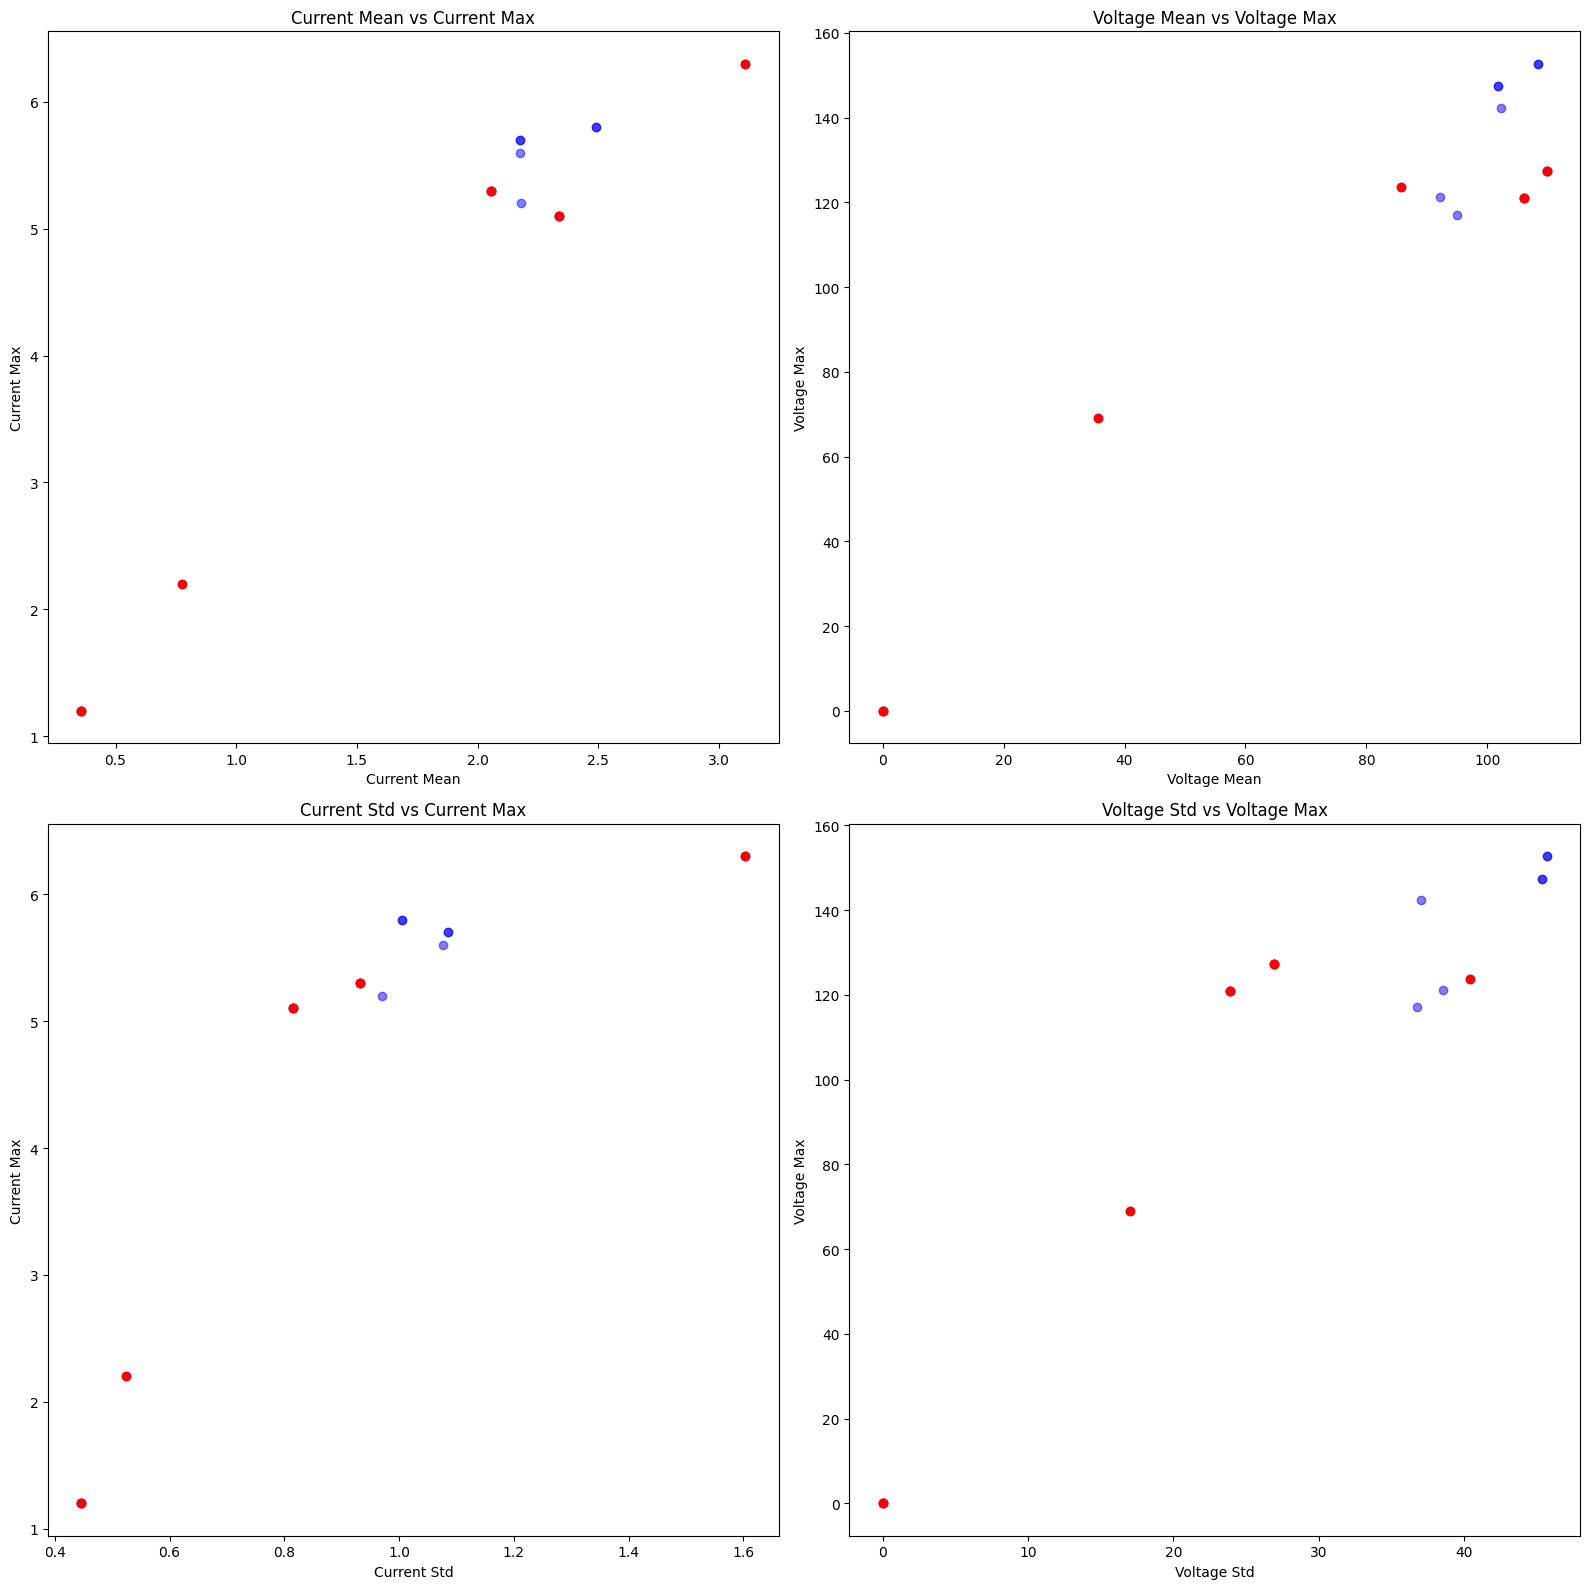

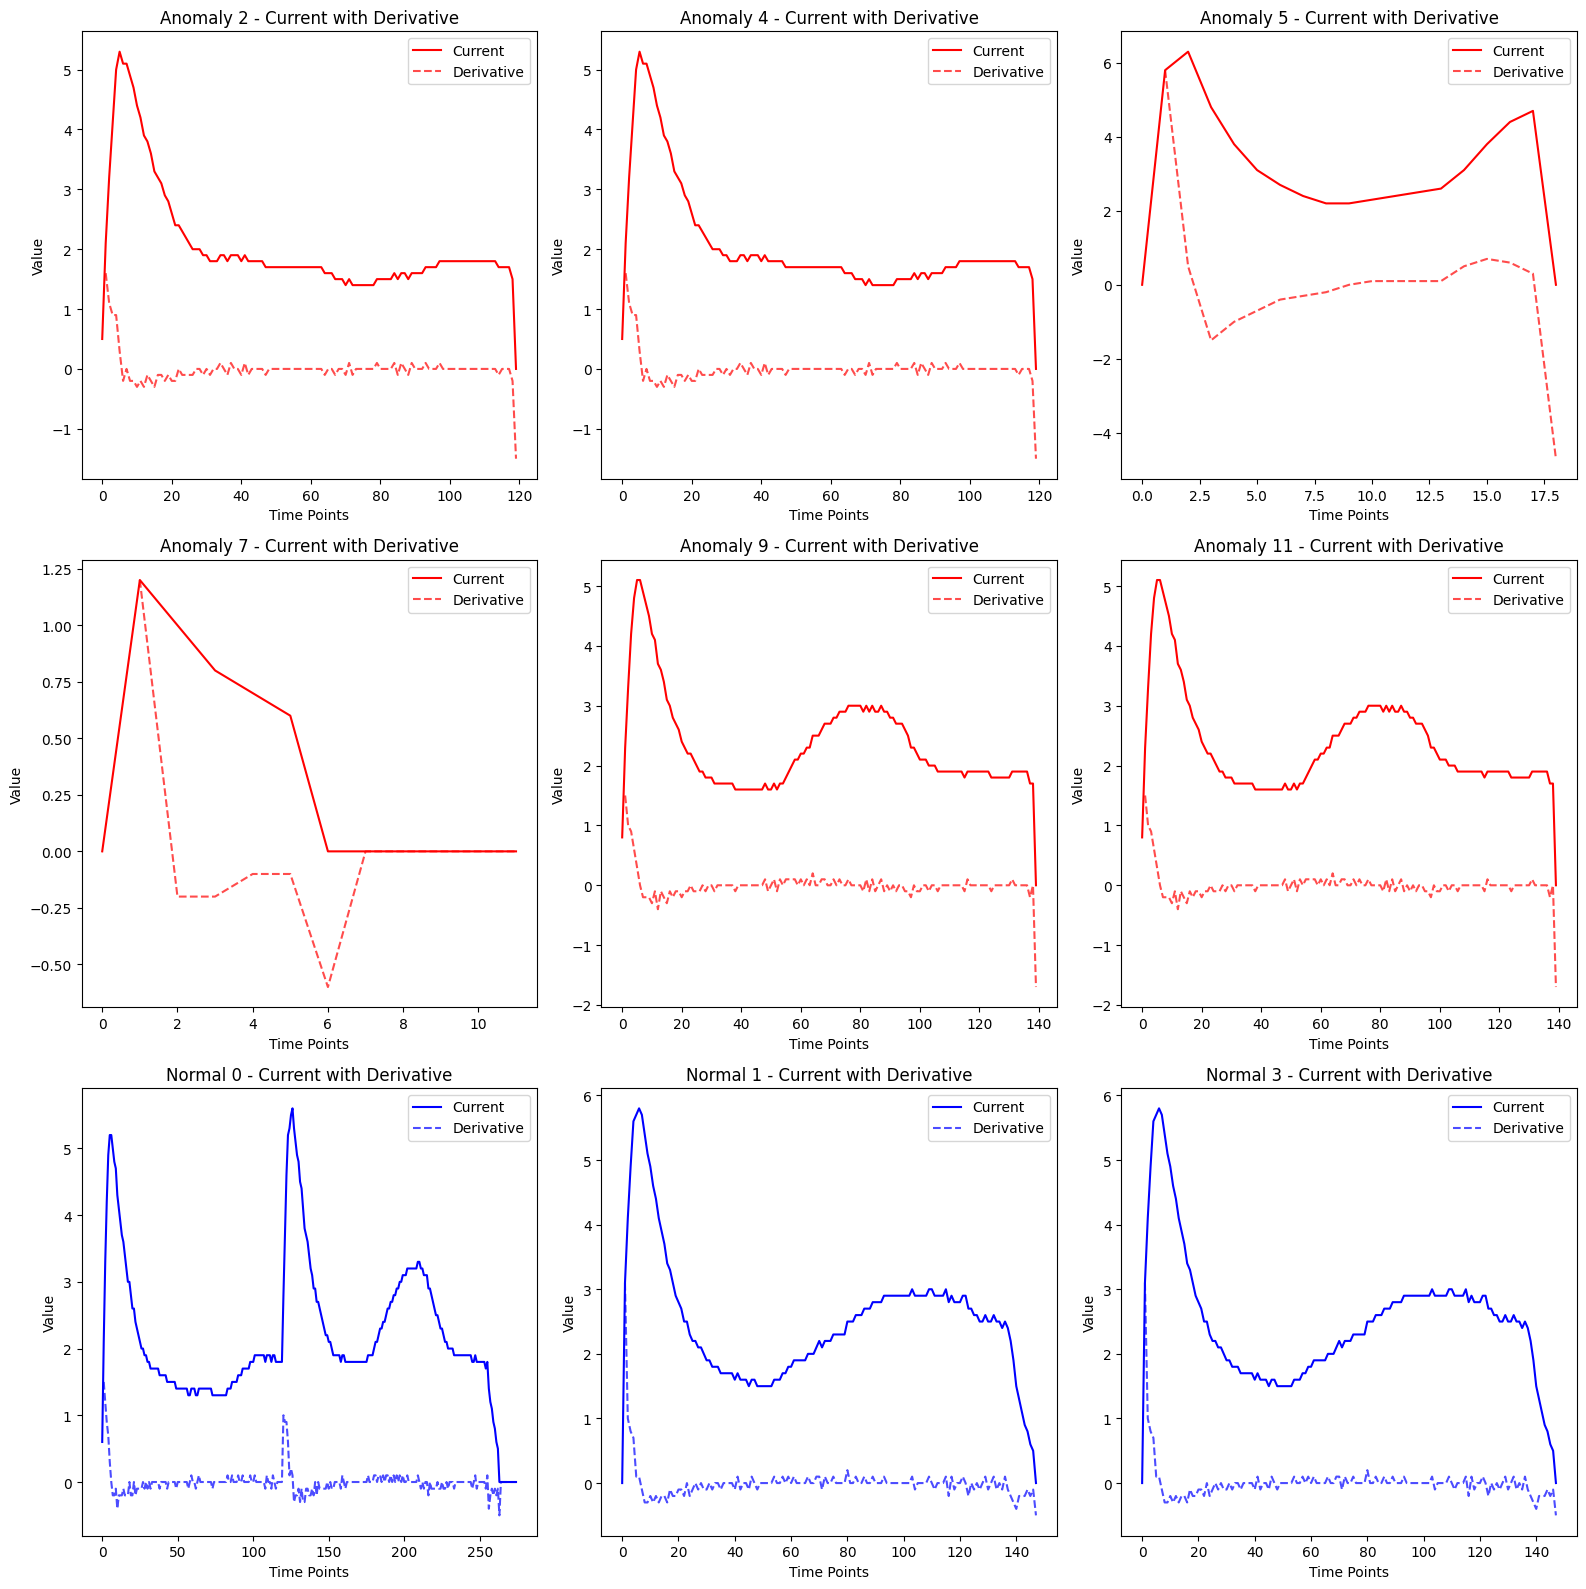

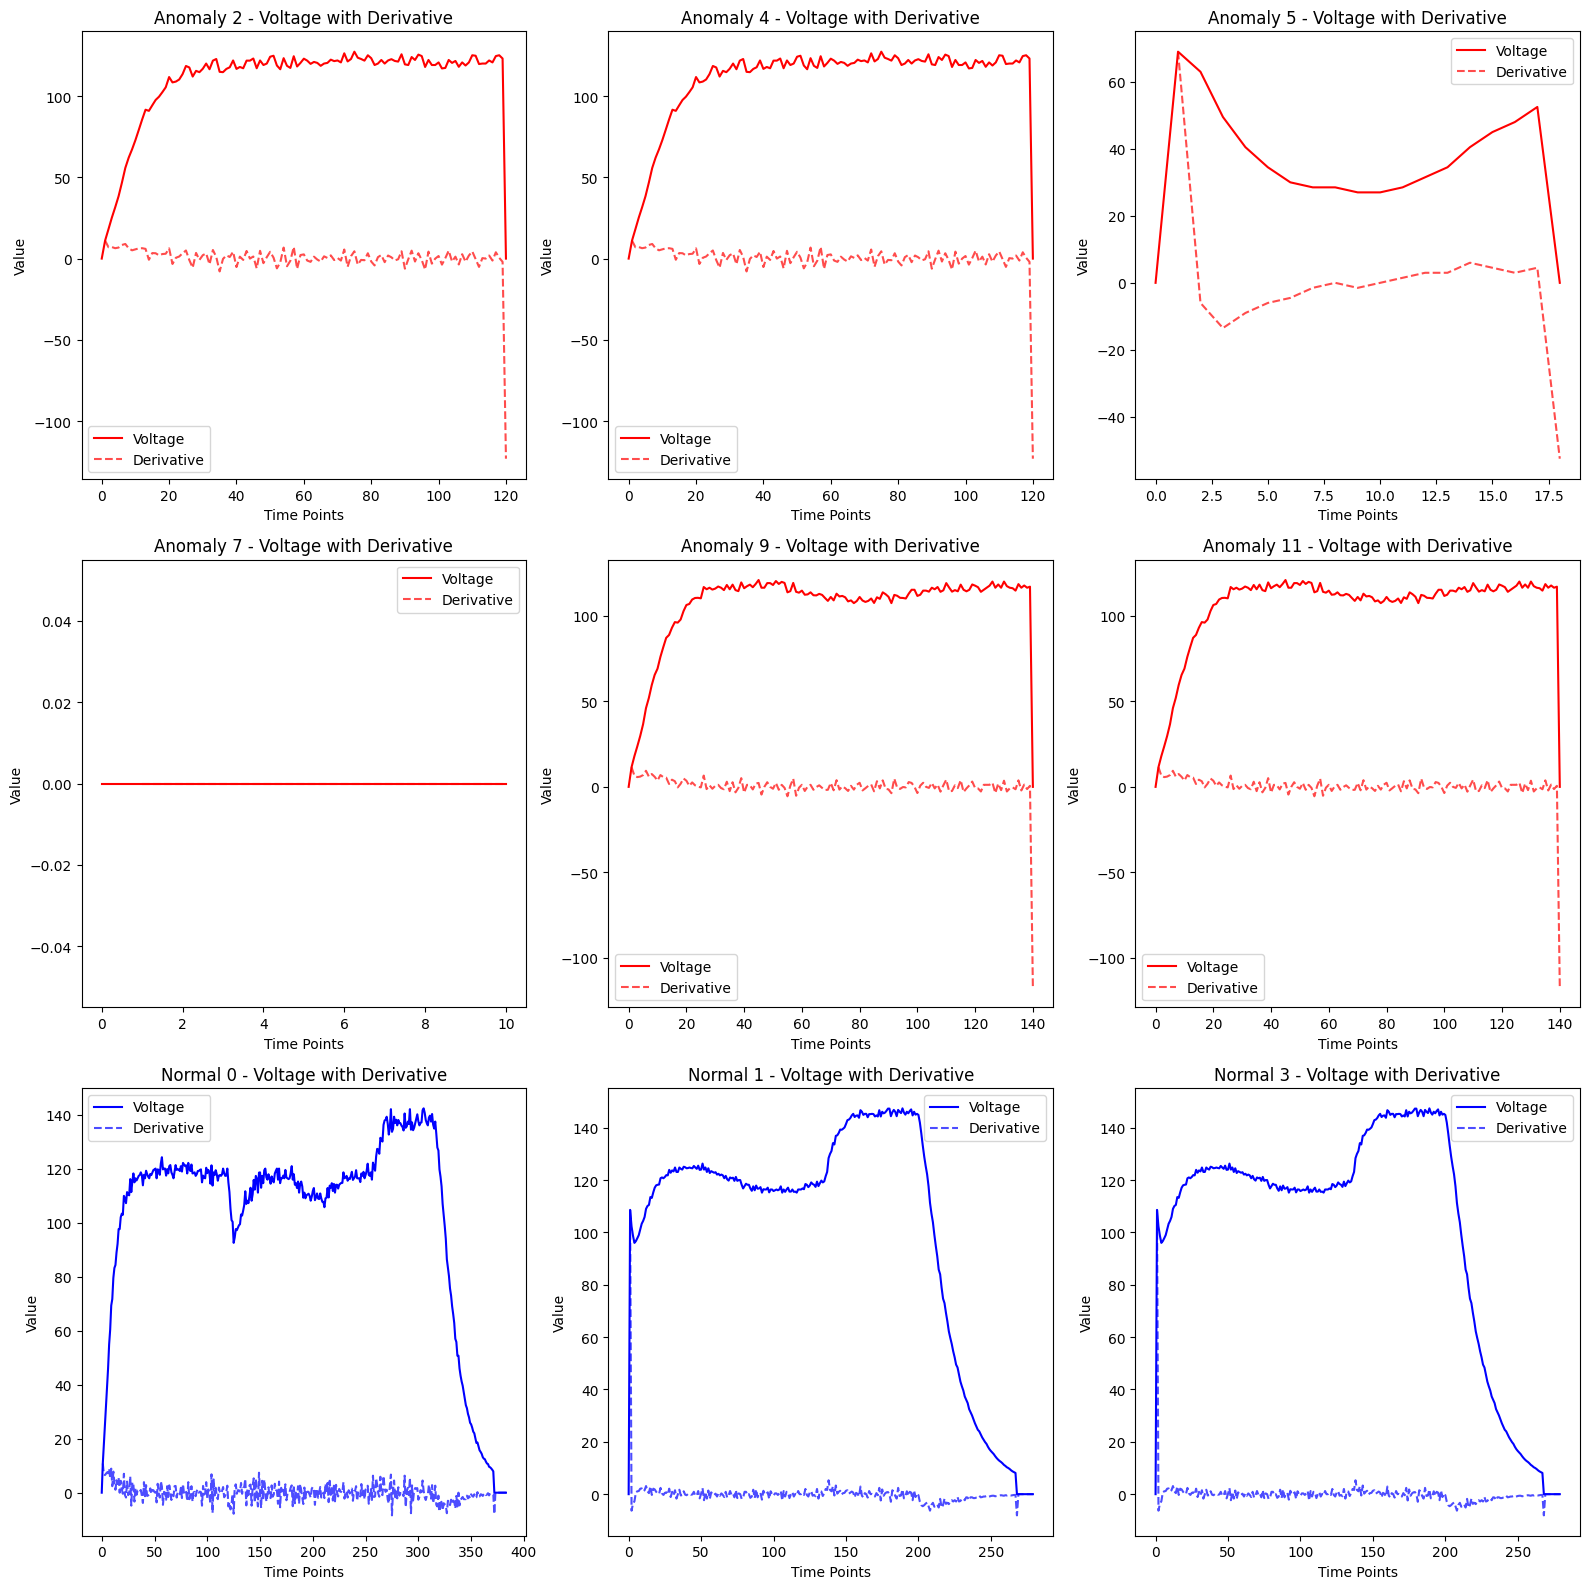

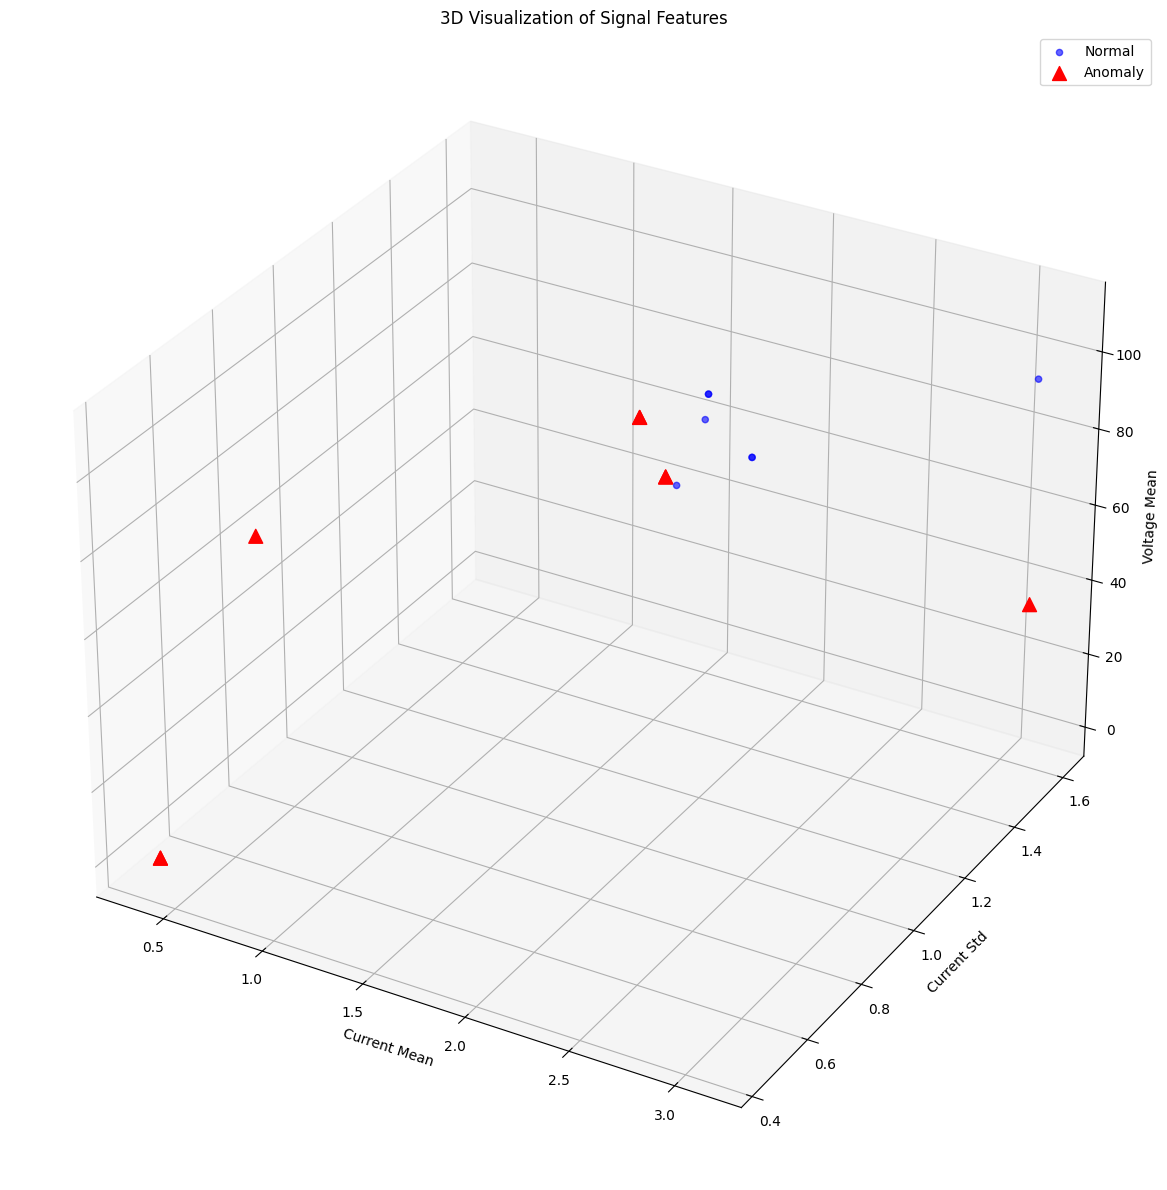

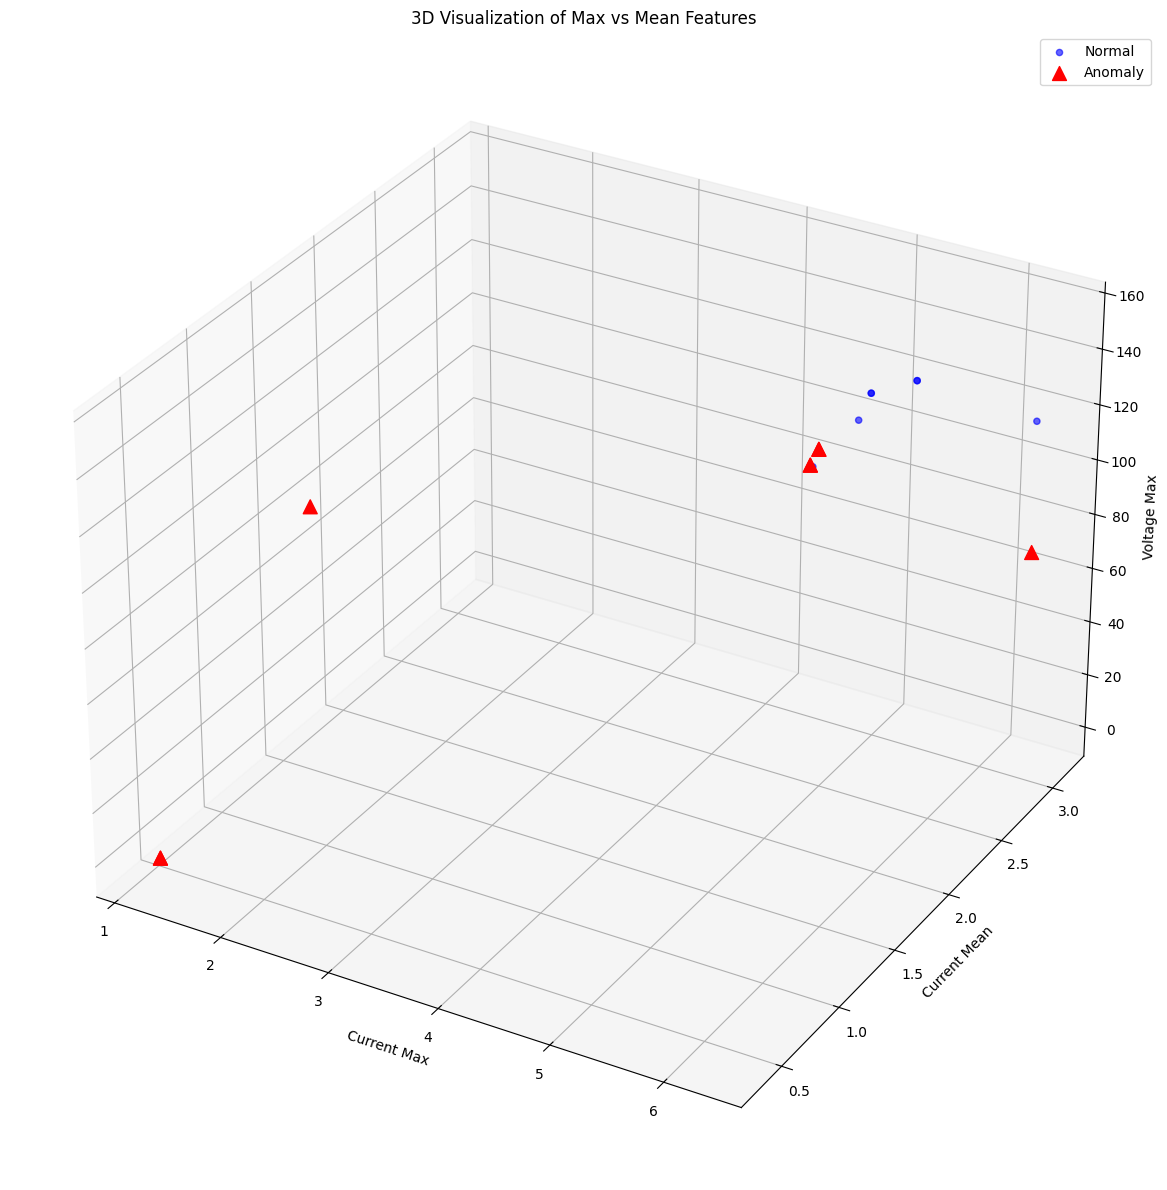

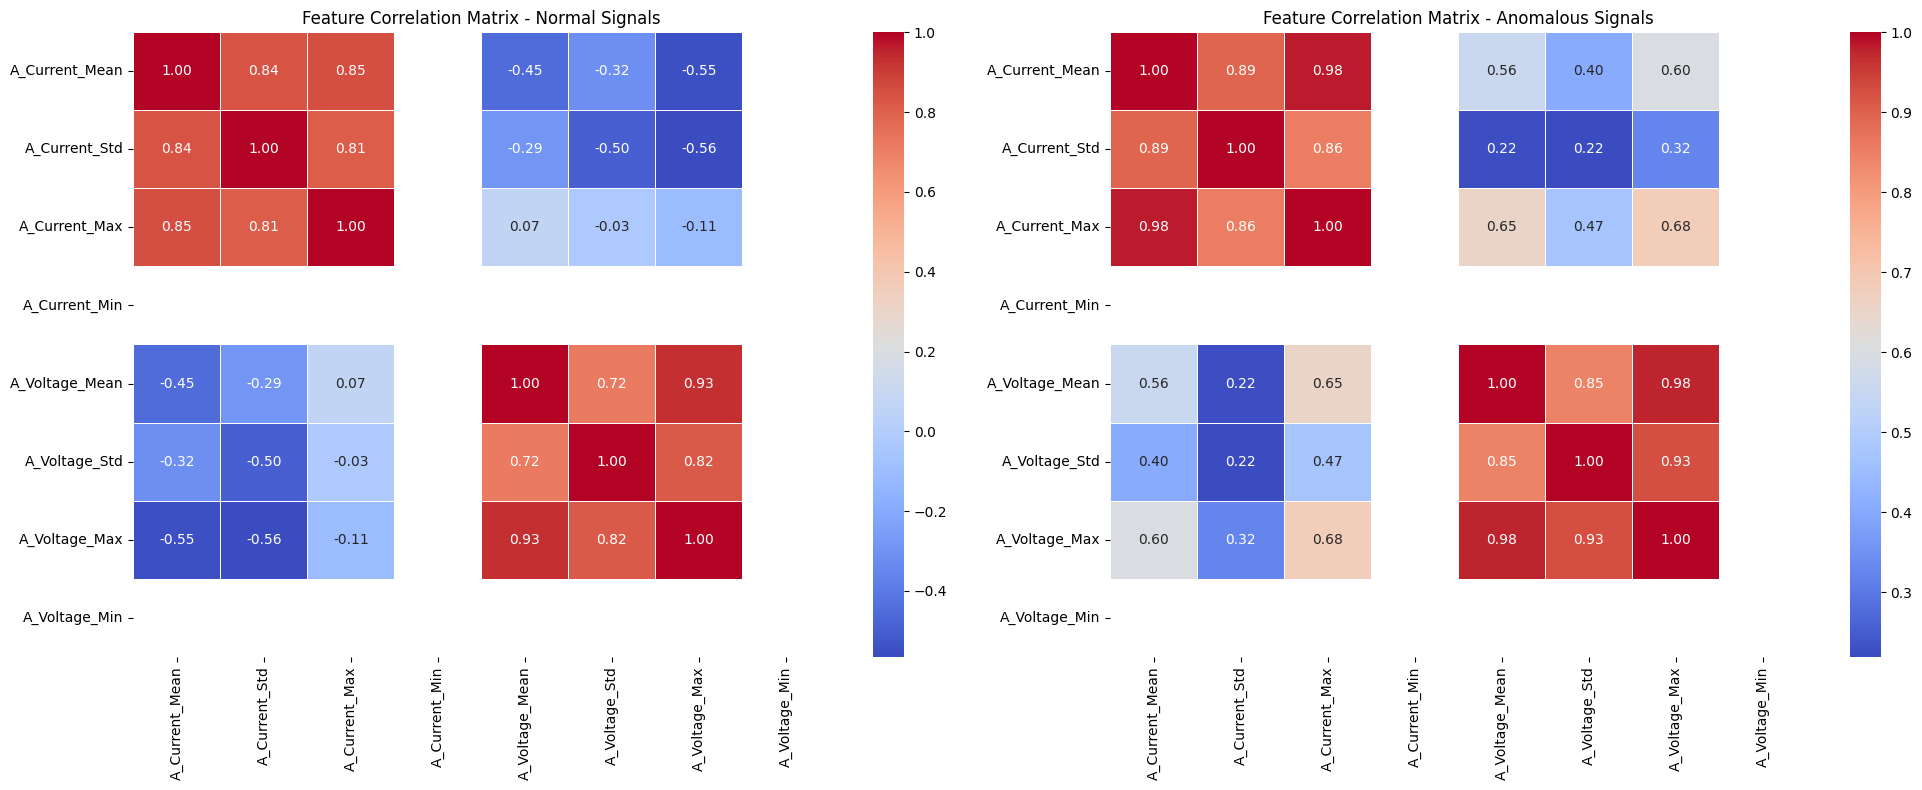

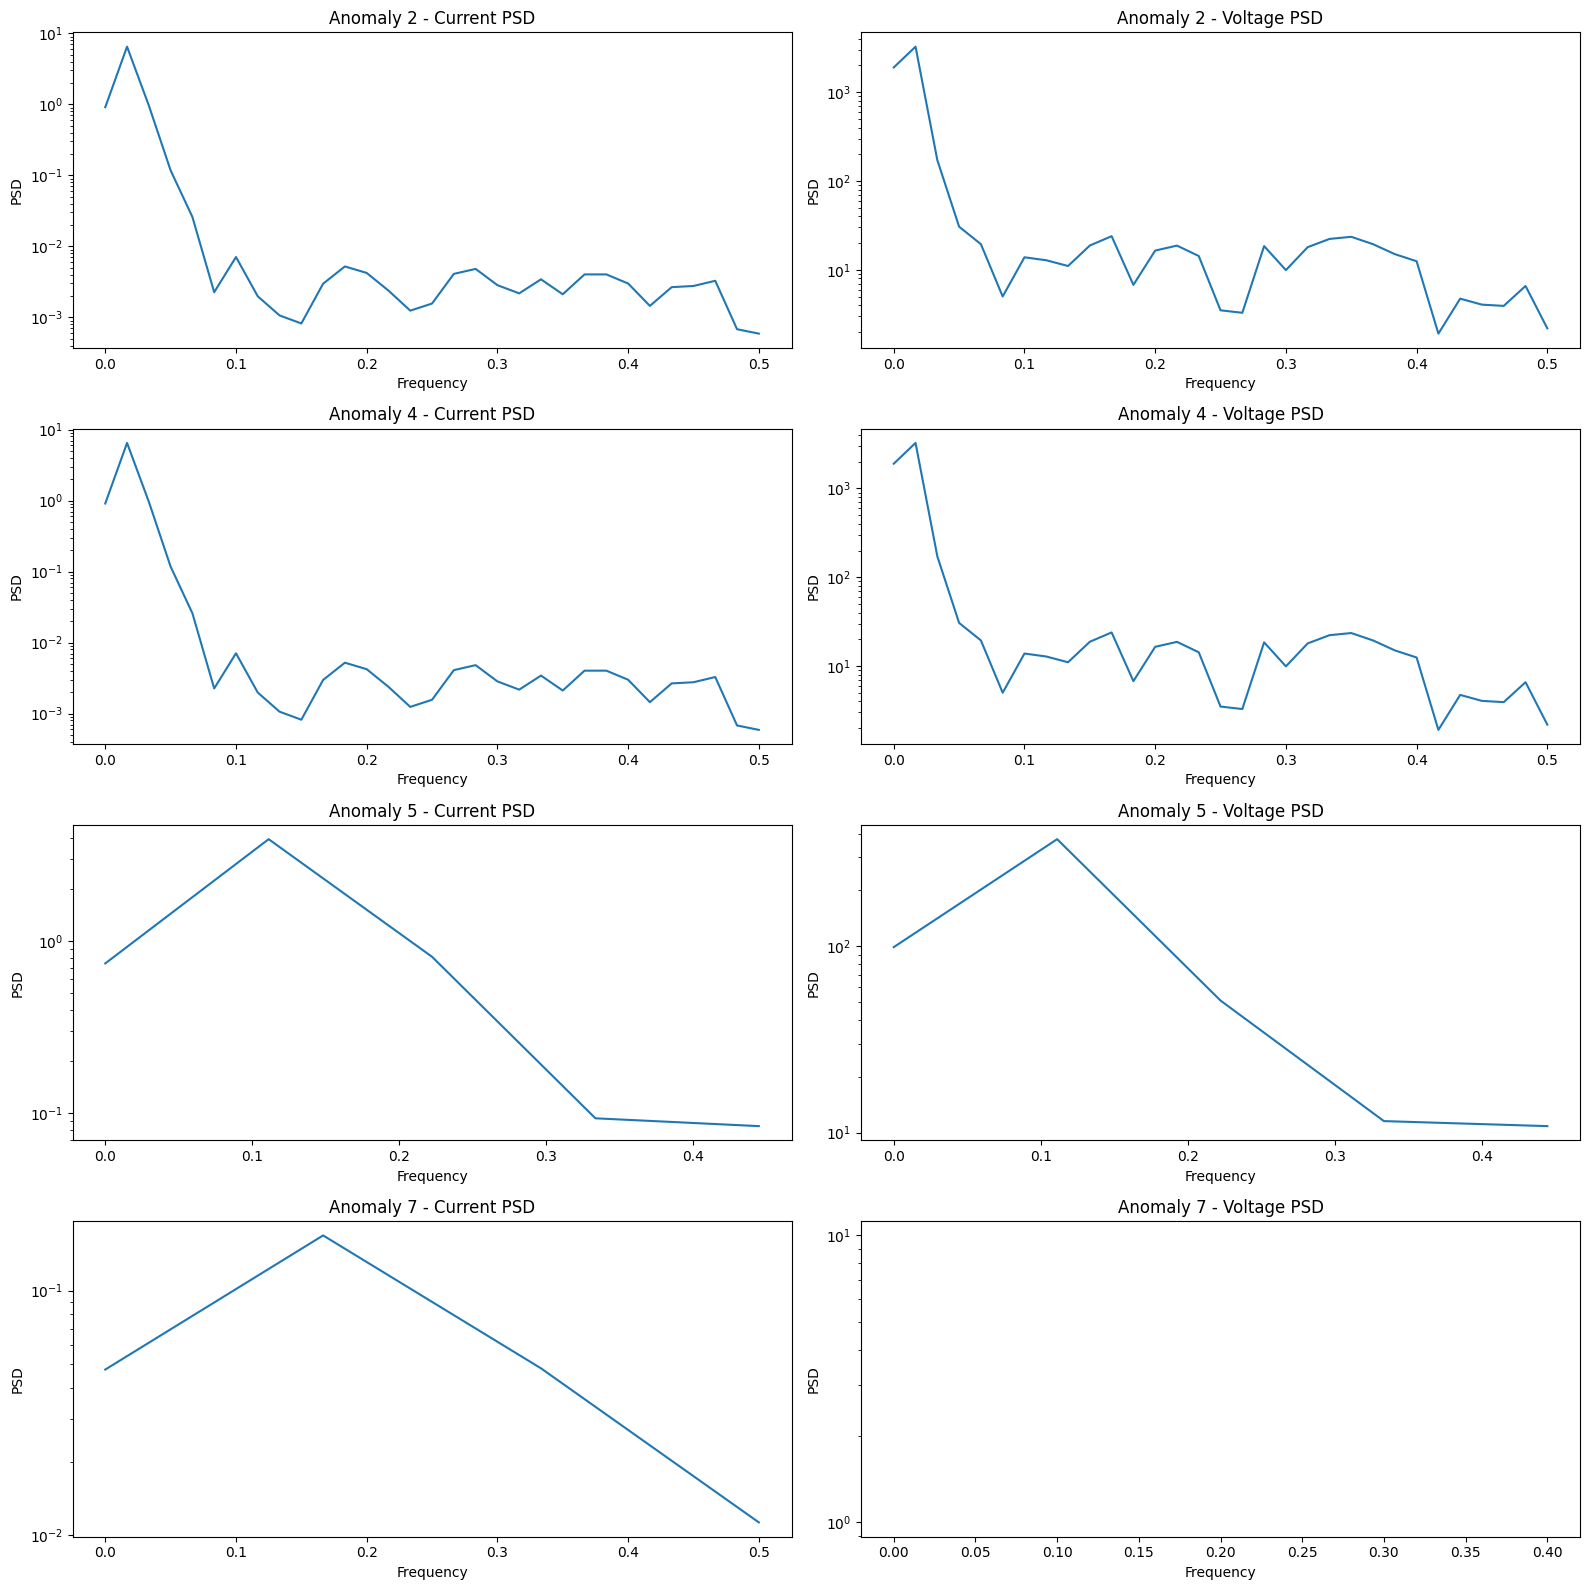

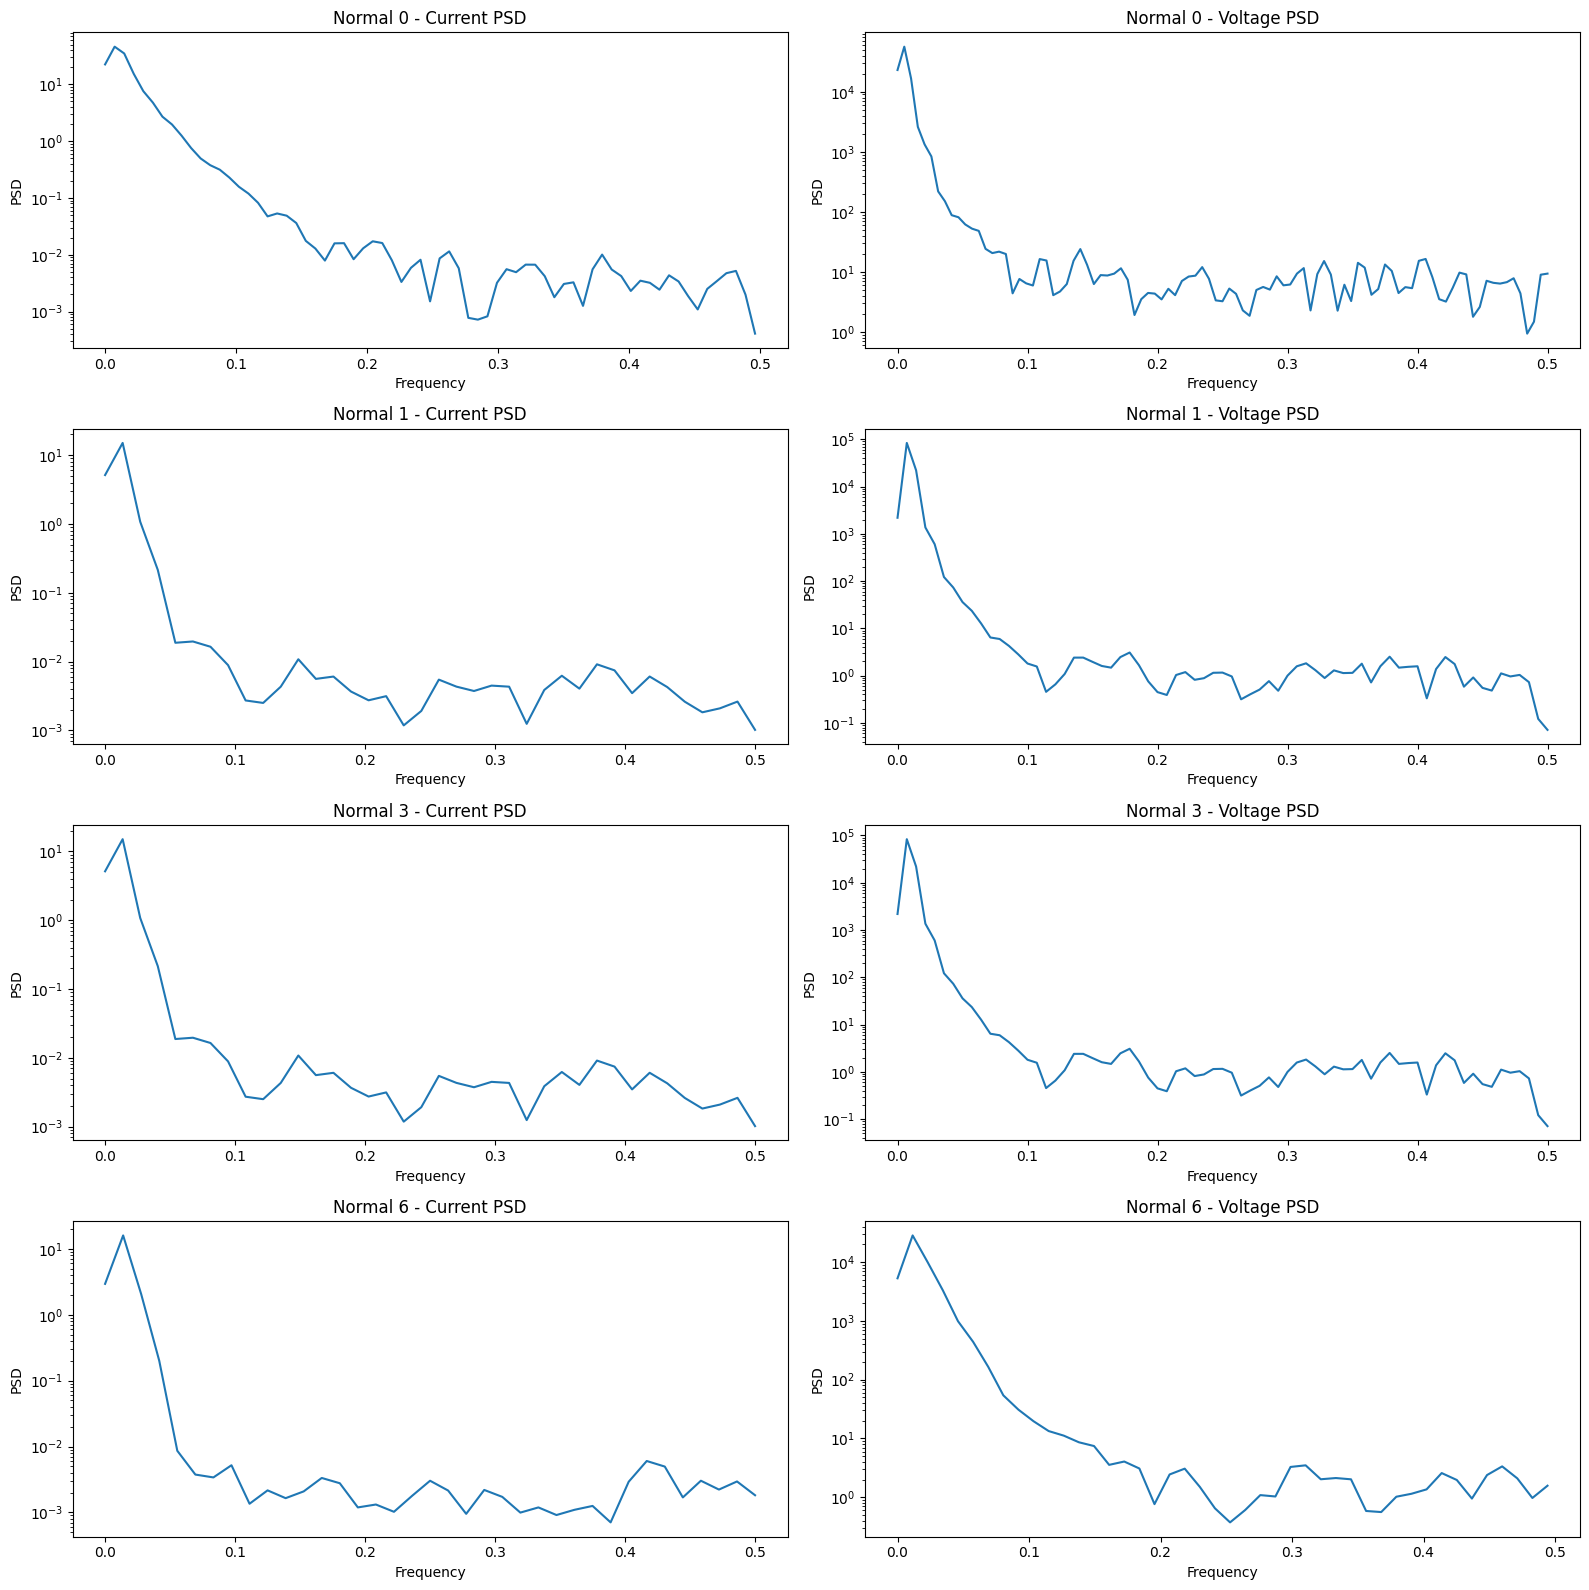

Analysis completed for FEB 2025 Prototype data\Test_Zone.csv


In [47]:
file_path = 'FEB 2025 Prototype data\Test_Zone.csv'
analyze_dataset_with_enhanced_graphs(file_path)